# Importing Stuff

In [1]:

from logging import raiseExceptions

import numpy as np
from sklearn.model_selection import train_test_split
#
from model import *
from preset import preset
from load_data import load_data_x, load_data_y, encode_data_y
from utils import *
#
import os
import time
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import TensorDataset
from ptflops import get_model_complexity_info
from itertools import permutations
from sklearn.metrics import classification_report, accuracy_score
from scipy.optimize import linear_sum_assignment
from train import train
from preset import preset
import torch.nn.functional as F
from utils import *
import wandb
from model.detr import *
from utils import *
device = torch.device("cpu")

In [2]:
def master_splitter(preset, var_task, var_model, var_users):
    env_data_x_train = []
    env_data_x_test = []
    env_data_y_train = []
    env_data_y_test = []
    for env in preset["data"]["environment"]:
        print(f"Loading data for {env} environment")
        data_pd_y = load_data_y(preset["path"]["data_y"],
                                var_environment=[env],
                                var_wifi_band=preset["data"]["wifi_band"],
                                var_num_users=var_users)
        #
        var_label_list = data_pd_y["label"].to_list()
        #
        ## load CSI amplitude
        X = load_data_x(preset["path"]["data_x"], var_label_list)


        y = encode_data_y(data_pd_y, var_task)

        if var_model == "THAT_MULTI_HEAD":
            y = reduce_dataset(y)  # CHECKKKKKKKK HEREEEEEE
        elif var_model == "THAT_ENCODER" or var_model == "DETR":
            y = reduce_dataset(y, preset["nn"]["num_obj_queries"])  # CHECKKKKKKKK HEREEEEEE
        elif var_model == "THAT_COUNT_CONSTRAINED":
            y_red = reduce_dataset(y)
            y = y_red.sum(axis=1)
        else:
            pass

        X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                            test_size=0.2,
                                                            shuffle=True,
                                                            random_state=103)
        # np.random.randint()
        env_data_x_train.append(X_train)
        env_data_x_test.append(X_test)
        env_data_y_train.append(y_train)
        env_data_y_test.append(y_test)
    
    data_x_train = np.concatenate(env_data_x_train, axis = 0)
    data_x_test = np.concatenate(env_data_x_test, axis = 0)
    data_y_train = np.concatenate(env_data_y_train, axis = 0)
    data_y_test = np.concatenate(env_data_y_test, axis = 0)


    return data_x_train, data_x_test, data_y_train, data_y_test

# Loading The Data and The Model

In [ ]:
load_path = "/home/amirmhd/Documents/multi_modal_CSI/benchmark/wifi_csi/results/model_0/PT_empty_DETR_MAINLeg.pth"
var_task = preset["task"]
var_model = preset["model"]
var_repeat = preset["repeat"]
var_users = ["0","1", "2", "3", "4", "5"]

In [4]:
data_train_x, data_test_x, data_train_y, data_test_y = master_splitter(preset, var_task, var_model, var_users)

Loading data for empty_room environment


In [5]:
data_train_x = data_train_x.reshape(data_train_x.shape[0], data_train_x.shape[1], -1)
data_test_x = data_test_x.reshape(data_test_x.shape[0], data_test_x.shape[1], -1)
var_x_shape, var_y_shape = data_train_x[0].shape, [data_train_y[0].shape[1]]

model_detr = DETR_MultiUser(var_x_shape,
                                    n_attention_heads=preset["nn"]["n_attention_heads"],
                                    features_dim=preset["nn"]["d_embedding"],
                                    embedding_time_dim=preset["nn"]["token_length"],
                                    num_decoder_layers=preset["nn"]["num_decoder_layers"],
                                    temp_cross=preset["nn"]["cross_attention_temp"],
                                    num_queries=preset["nn"]["num_obj_queries"],
                                    dim_feedforward=preset["nn"]["dim_FFN"]).to(device)

In [6]:
state_dict = torch.load(load_path, map_location=device)
model_detr.load_state_dict(state_dict)



<All keys matched successfully>

# Geting predictions for the model

Here we can further split the test set to valid and test sets.

In [7]:
# data_valid_x, data_test_x, data_valid_y, data_test_y = train_test_split(data_test_x, data_test_y,
#                                                                     test_size=0.5,
#                                                                     shuffle=True,
#                                                                 random_state=39)

In [8]:
with torch.no_grad():
        predict_test_y = model_detr(torch.from_numpy(data_test_x).to(device))
predict_test_y = predict_test_y.detach().cpu().numpy()
#
var_time_2 = time.time()
#
## -------------------------------------- Evaluate ----------------------------------------
#
##

layers_idxs = preset["layers_idxs"]

# Store results for each layer
all_layers_results = {}
dict_layer_acc = performance_metrics(data_test_y, predict_test_y, var_mode="multi_head")

# Process each layer separately
for idx, layer_idx in enumerate(layers_idxs):

    layer_metrics = dict_layer_acc[layer_idx]

    # Log metrics for this layer
# In the test results section of run_that_detr
    print(layer_metrics)

{'total_error': 1.5809018567639257, 'perfect_prediction_percentage': 44.297082228116714, 'accuracy': 0.8397608251190892, 'error_per_person': [0.6178861788617886, 1.1886792452830188, 2.3, 2.278688524590164, 3.2142857142857144], 'mean_count_error': 0.10610079575596817, 'counting_error_perPerson': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.

# Analysis

In [18]:
predict_test_y_last = predict_test_y[-1].argmax(axis=2)
y_test = data_test_y.argmax(axis=2)

print(y_test.shape)


(377, 7)


## Seeing how each query is prediciting what?

In [14]:
predict_test_y_last[0]

array([4, 3, 9, 4, 9, 3, 3])

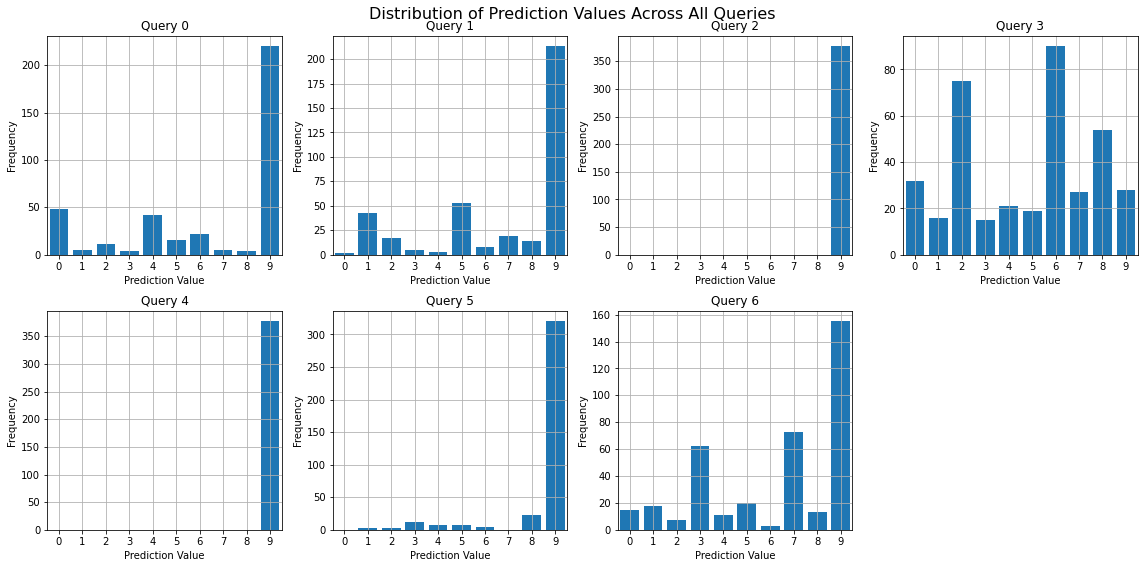

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing
num_queries = 7  
for query_idx in range(num_queries):
    ax = axes[query_idx]
    ax.hist(predict_test_y_last[:, query_idx], bins=range(11), align='left', rwidth=0.8)
    ax.set_xticks(range(10))
    ax.set_xlim(-0.5, 9.5)  # Set proper limits for better visualization
    ax.set_xlabel('Prediction Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Query {query_idx}')
    ax.grid(True)
for idx in range(num_queries, len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()  # Adjust the spacing between subplots
plt.suptitle('Distribution of Prediction Values Across All Queries', fontsize=16)
plt.subplots_adjust(top=0.93)  # Make room for the suptitle
plt.show()

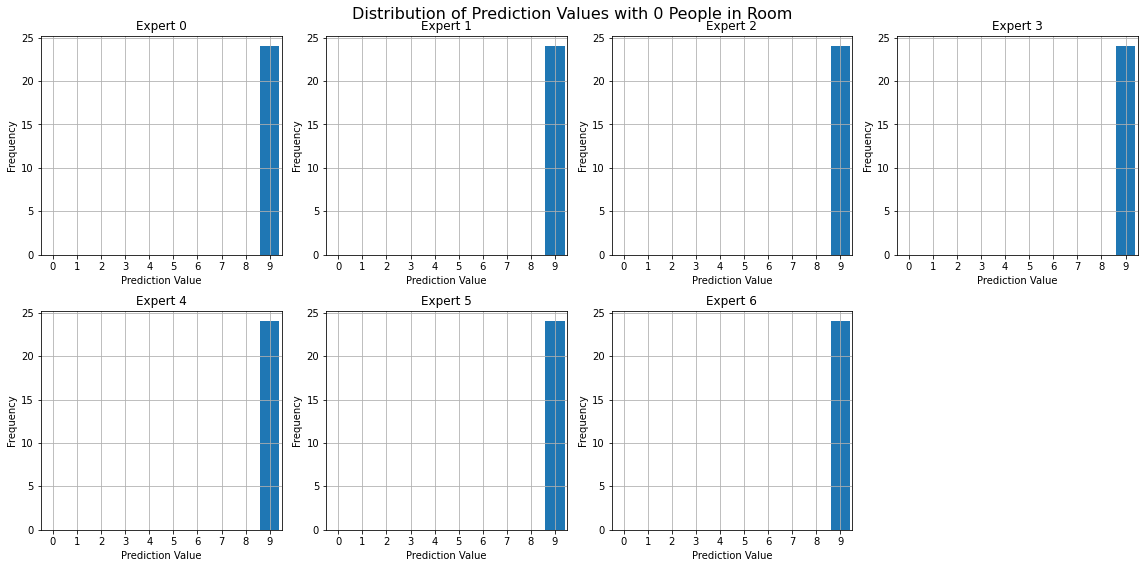

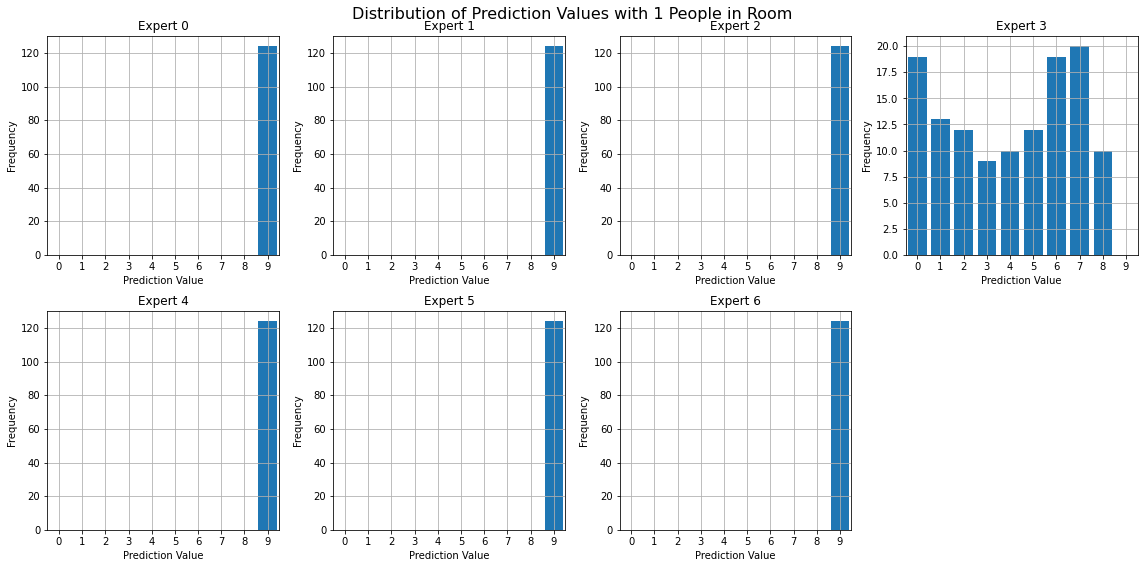

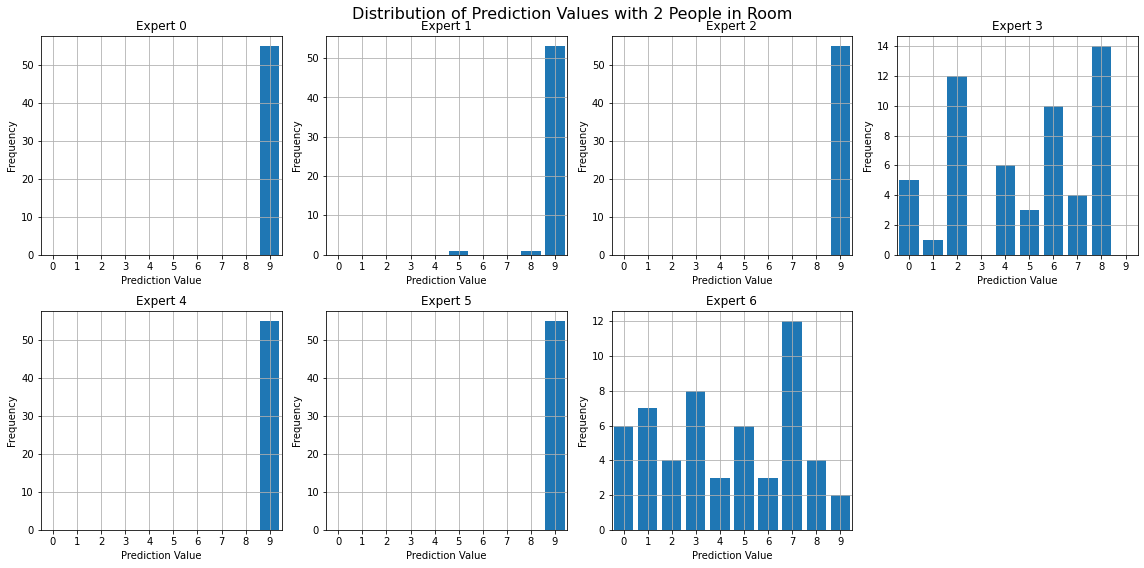

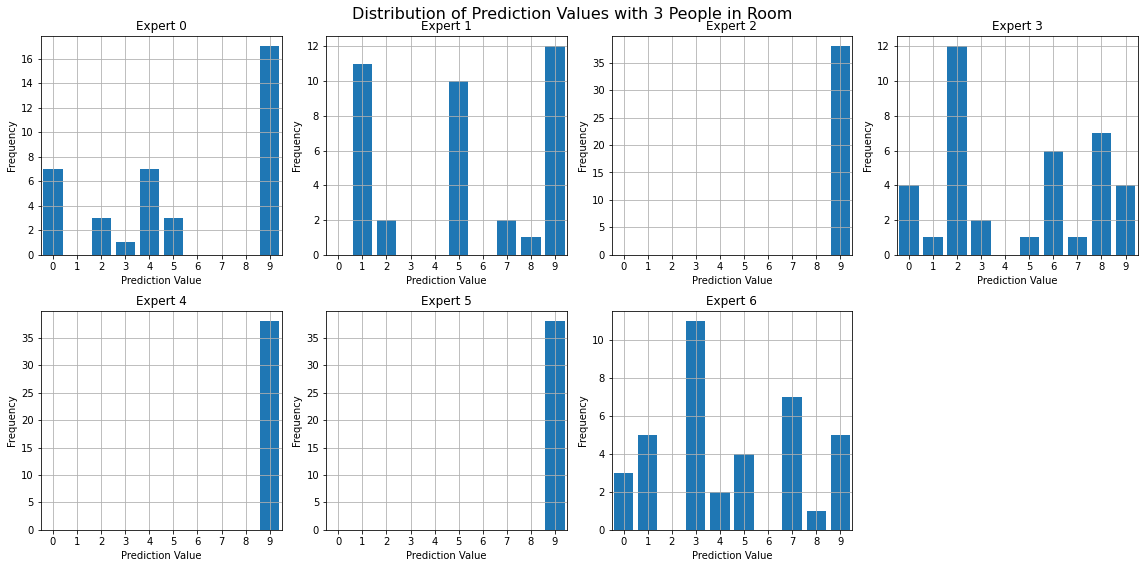

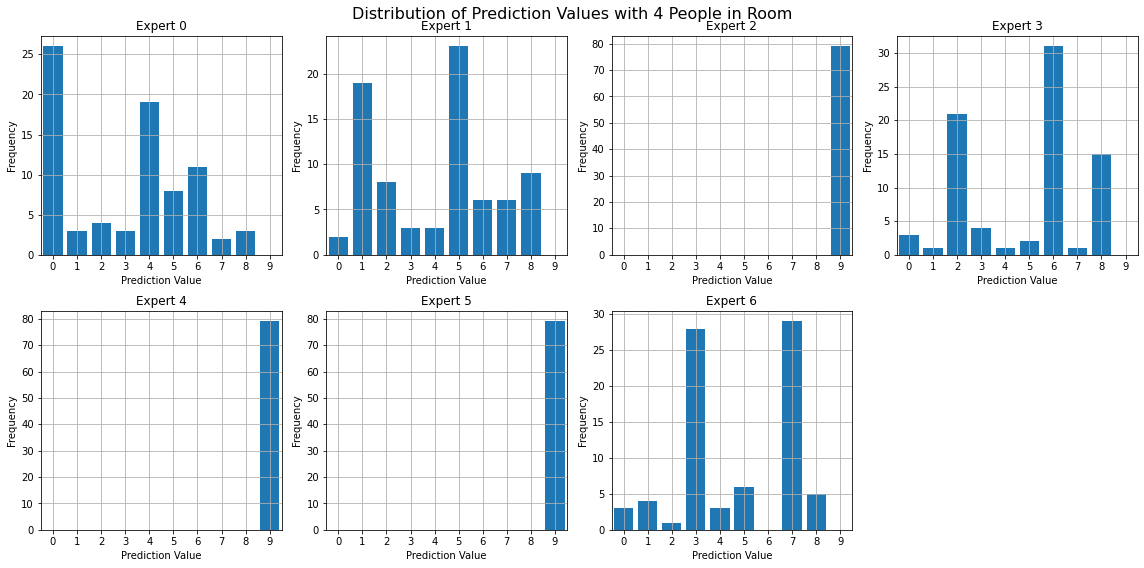

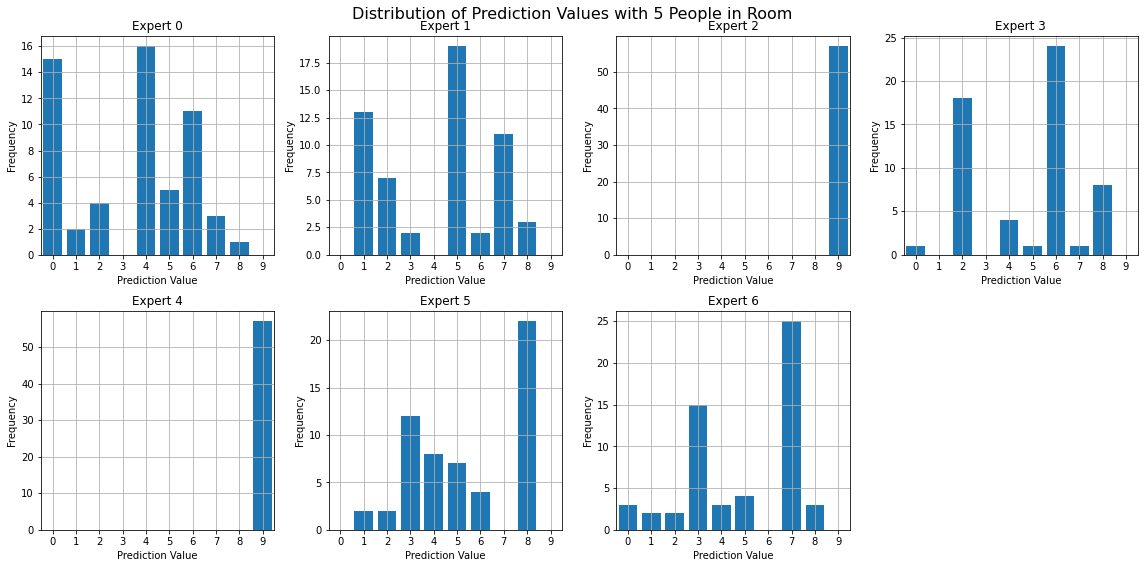

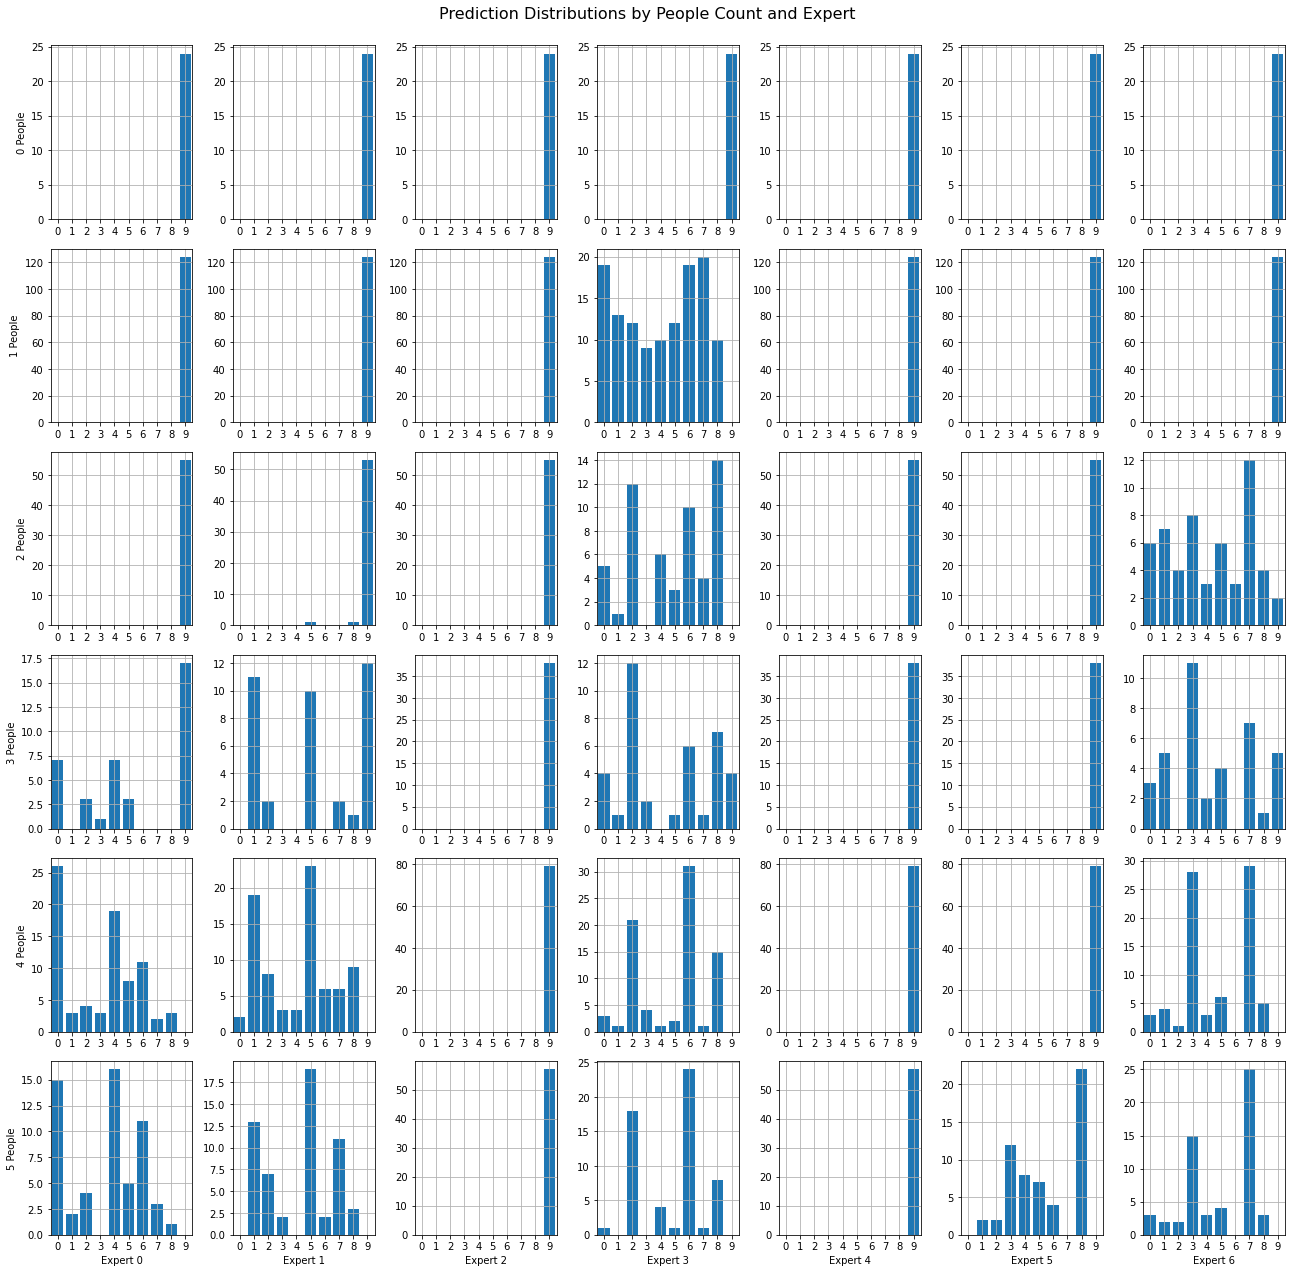

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Assuming predict_test_y_last is your array of predictions
# where each row is an instance and each column is an expert's prediction

# Step 1: Determine people count for each instance
# Method: Count predictions that are not 9 ("no person")
def count_people(predictions_row):
    # This is one simple approach - you may need to adjust based on your exact requirements
    # Here we're counting the number of experts who didn't predict "no person"
    return sum(1 for pred in predictions_row if pred != 9)

# Calculate people count for each instance
people_counts = [count_people(row) for row in predict_test_y_last]

# Group instances by people count
instances_by_count = defaultdict(list)
for idx, count in enumerate(people_counts):
    instances_by_count[count].append(idx)

# Create visualization for each people count
unique_counts = sorted(instances_by_count.keys())
num_queries = 7

for people_count in unique_counts:
    if len(instances_by_count[people_count]) < 5:  # Skip if too few samples
        continue
        
    # Get indices of instances with this people count
    indices = instances_by_count[people_count]
    
    # Create subplots
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for query_idx in range(num_queries):
        ax = axes[query_idx]
        
        # Get predictions for this query and people count
        predictions = predict_test_y_last[indices, query_idx]
        
        # Create histogram
        ax.hist(predictions, bins=range(11), align='left', rwidth=0.8)
        ax.set_xticks(range(10))
        ax.set_xlim(-0.5, 9.5)
        ax.set_xlabel('Prediction Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Expert {query_idx}')
        ax.grid(True)
    
    # Remove any unused subplots
    for idx in range(num_queries, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.suptitle(f'Distribution of Prediction Values with {people_count} People in Room', fontsize=16)
    plt.subplots_adjust(top=0.93)
    plt.show()

# Alternative: Create a grid where rows are people counts and columns are experts
max_people = max(unique_counts)
if max_people < 8:  # Only create this visualization if there aren't too many people counts
    fig, axes = plt.subplots(max_people + 1, num_queries, figsize=(18, 3*(max_people+1)))
    
    for people_count in range(max_people + 1):
        if people_count in instances_by_count:
            indices = instances_by_count[people_count]
            
            for query_idx in range(num_queries):
                ax = axes[people_count, query_idx]
                
                # Get predictions for this query and people count
                predictions = predict_test_y_last[indices, query_idx]
                
                # Create histogram
                ax.hist(predictions, bins=range(11), align='left', rwidth=0.8)
                ax.set_xticks(range(10))
                ax.set_xlim(-0.5, 9.5)
                
                # Only add labels on the edges
                if query_idx == 0:
                    ax.set_ylabel(f'{people_count} People')
                if people_count == max_people:
                    ax.set_xlabel(f'Expert {query_idx}')
                
                ax.grid(True)
    
    plt.tight_layout()
    plt.suptitle('Prediction Distributions by People Count and Expert', fontsize=16)
    plt.subplots_adjust(top=0.95)
    plt.show()

Here we add pericison on top of each bar.

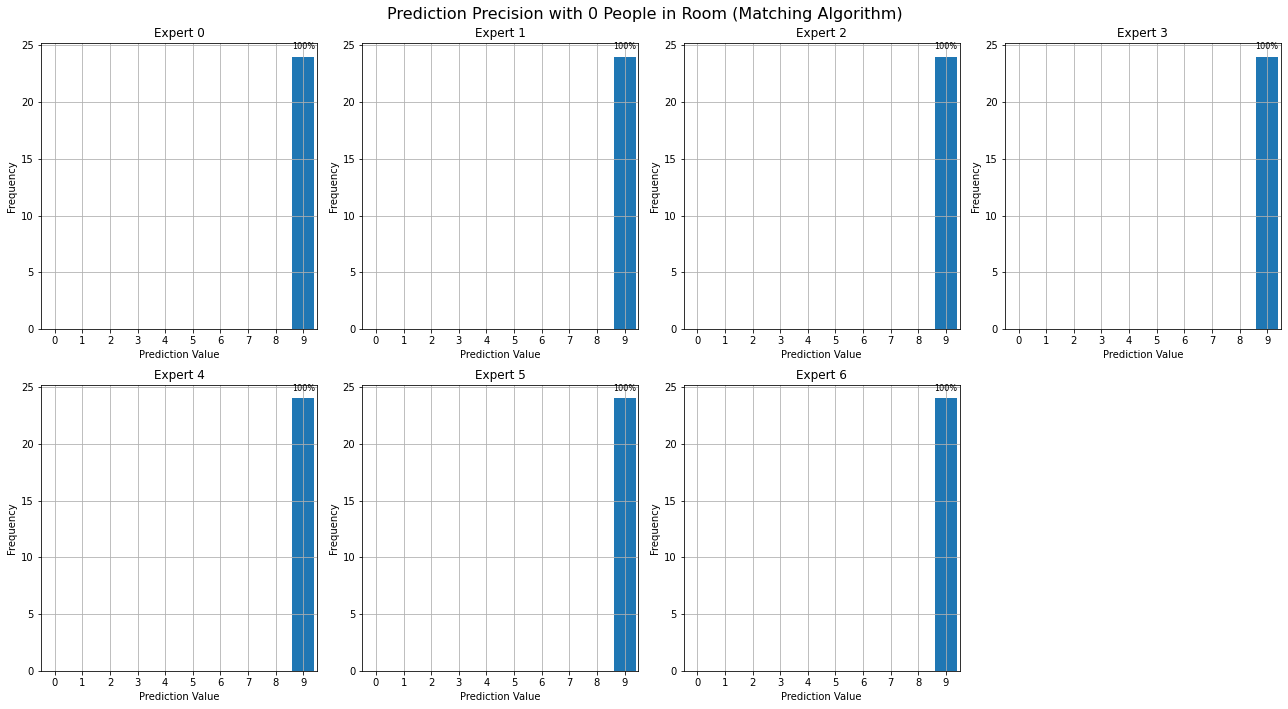

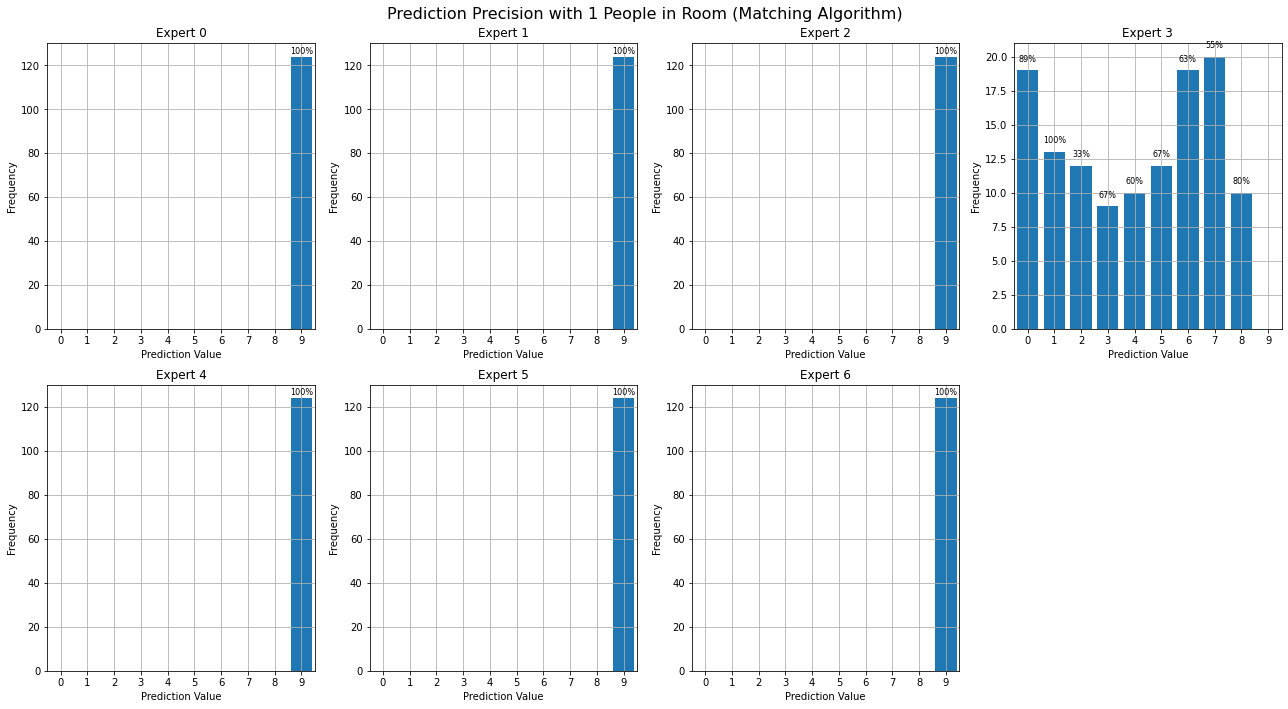

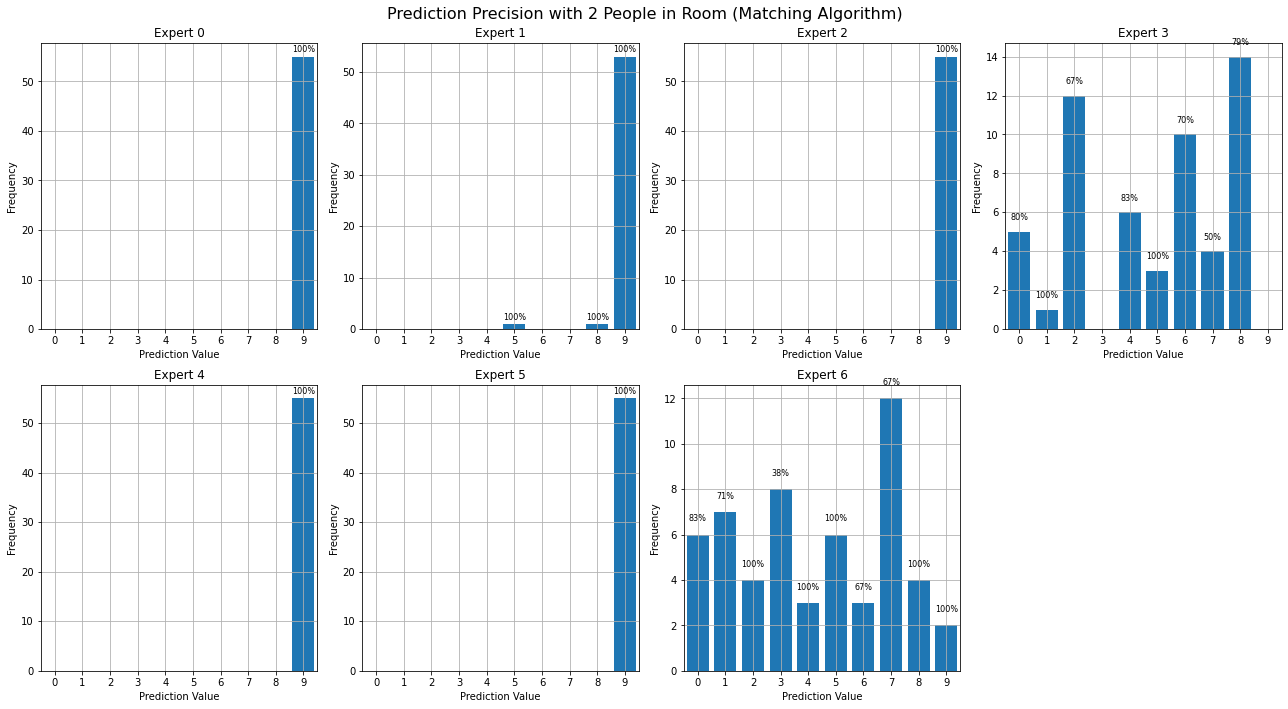

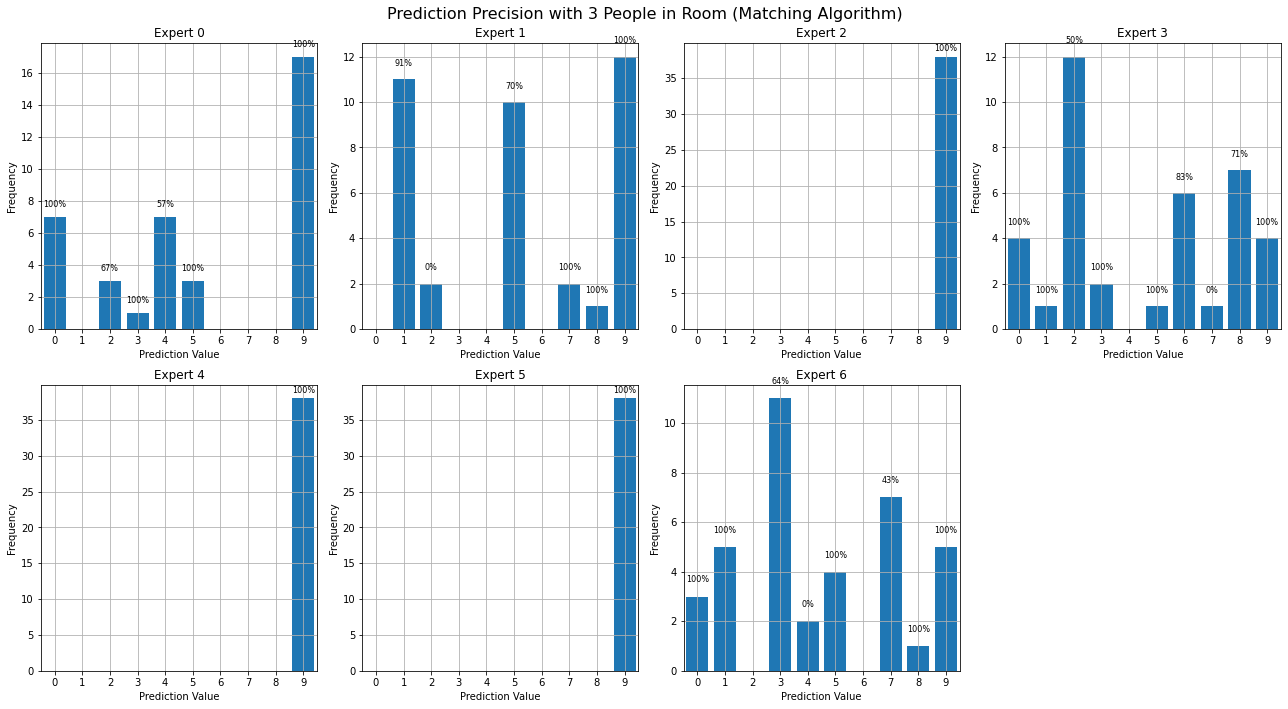

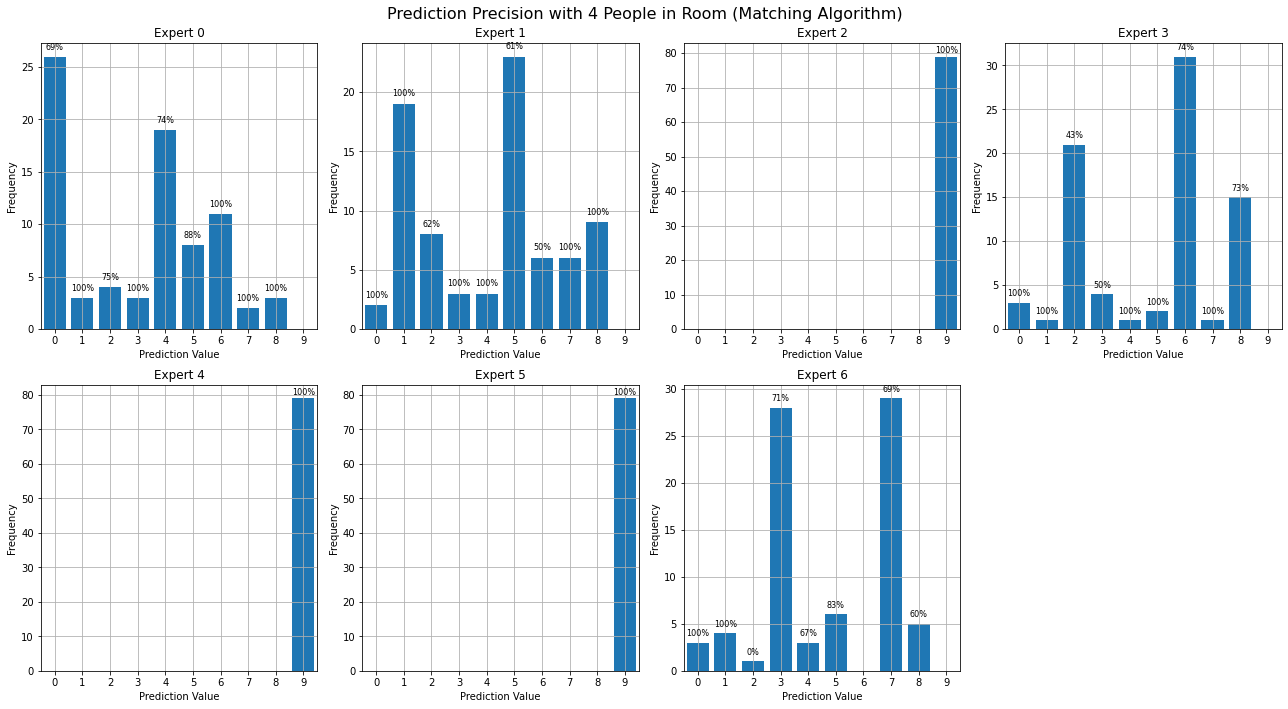

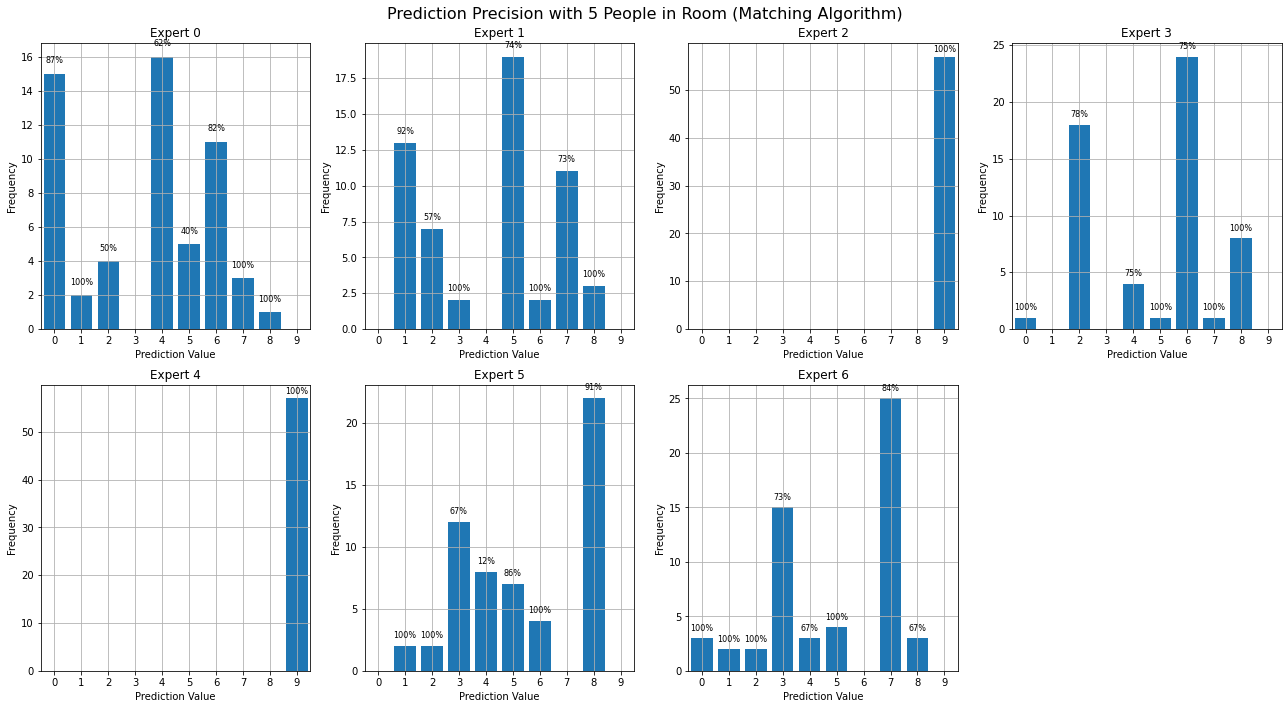

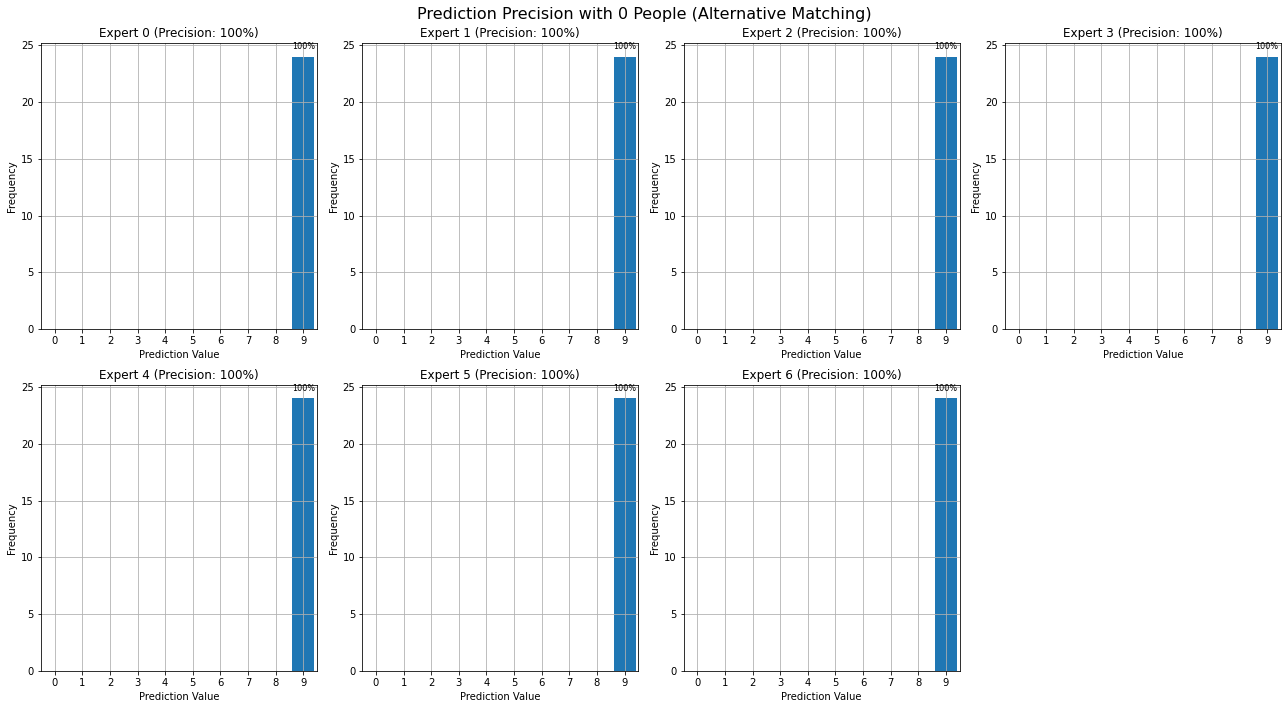

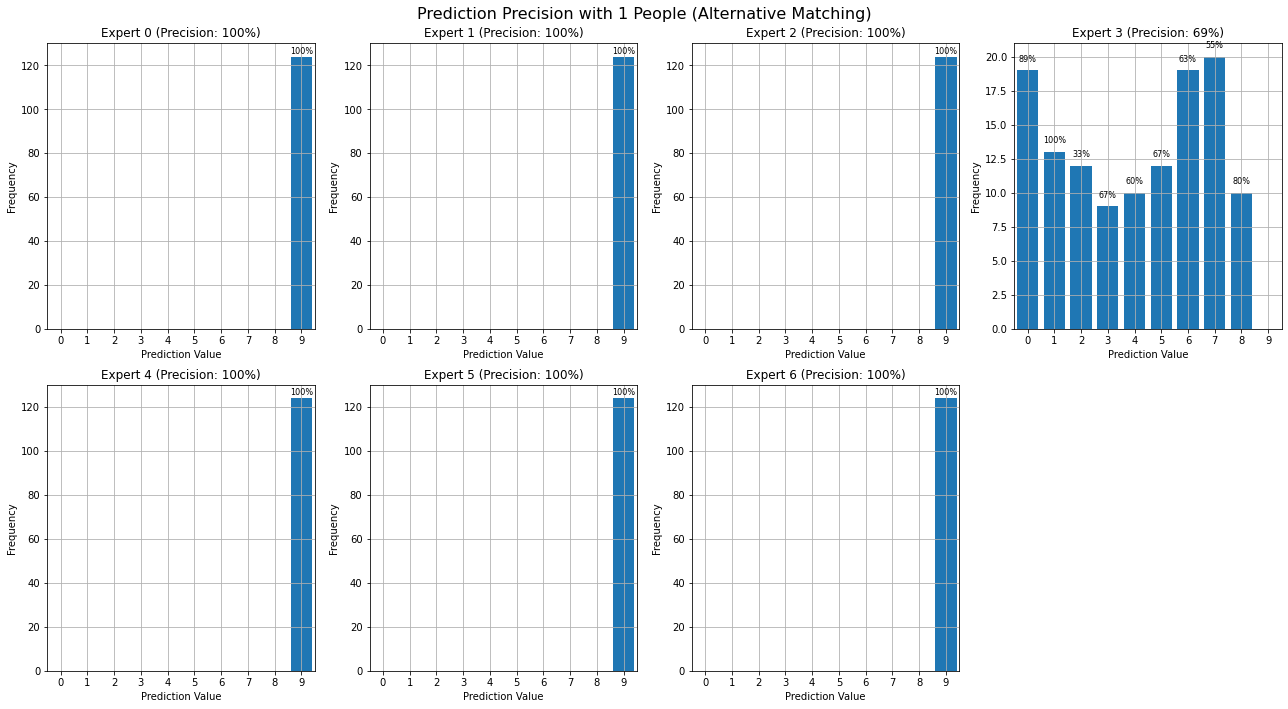

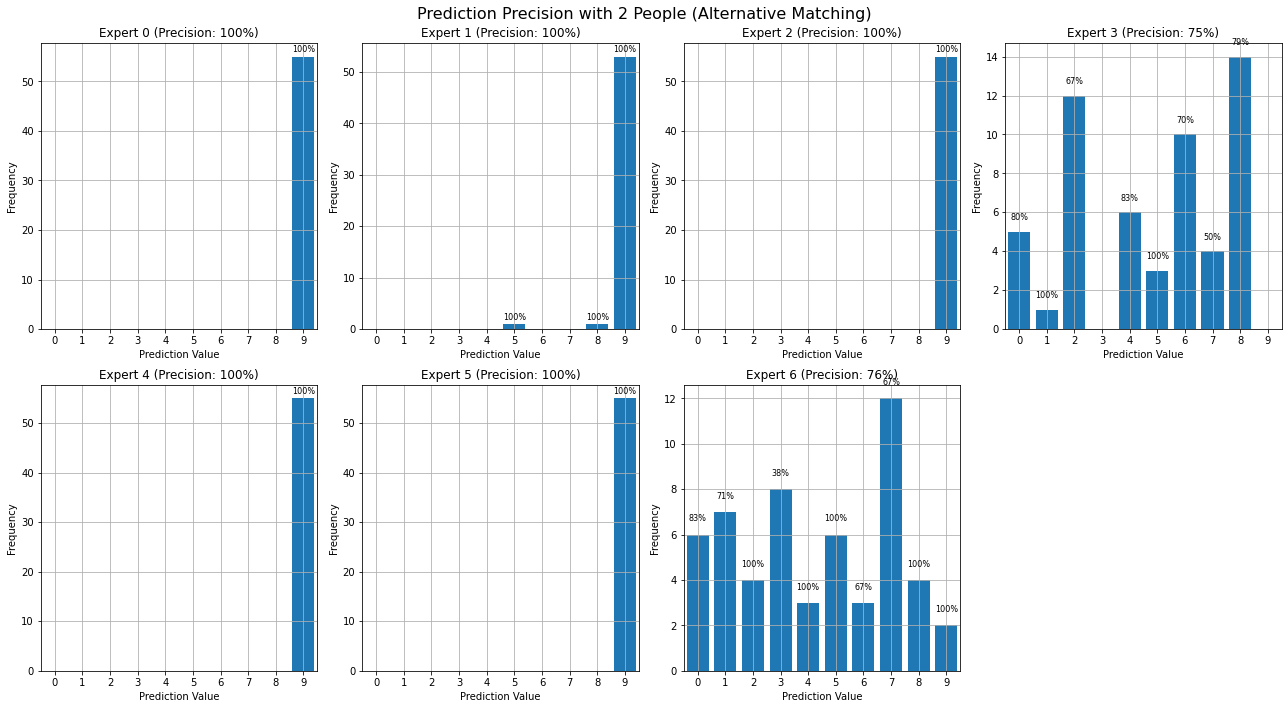

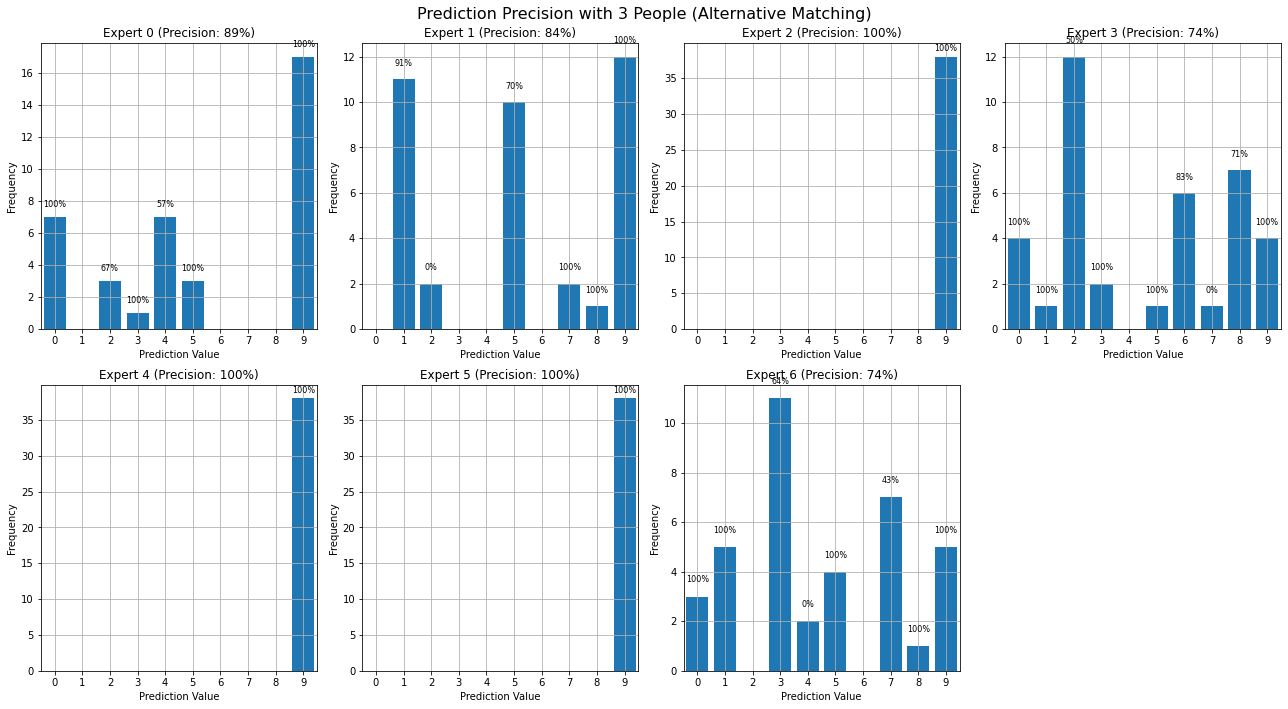

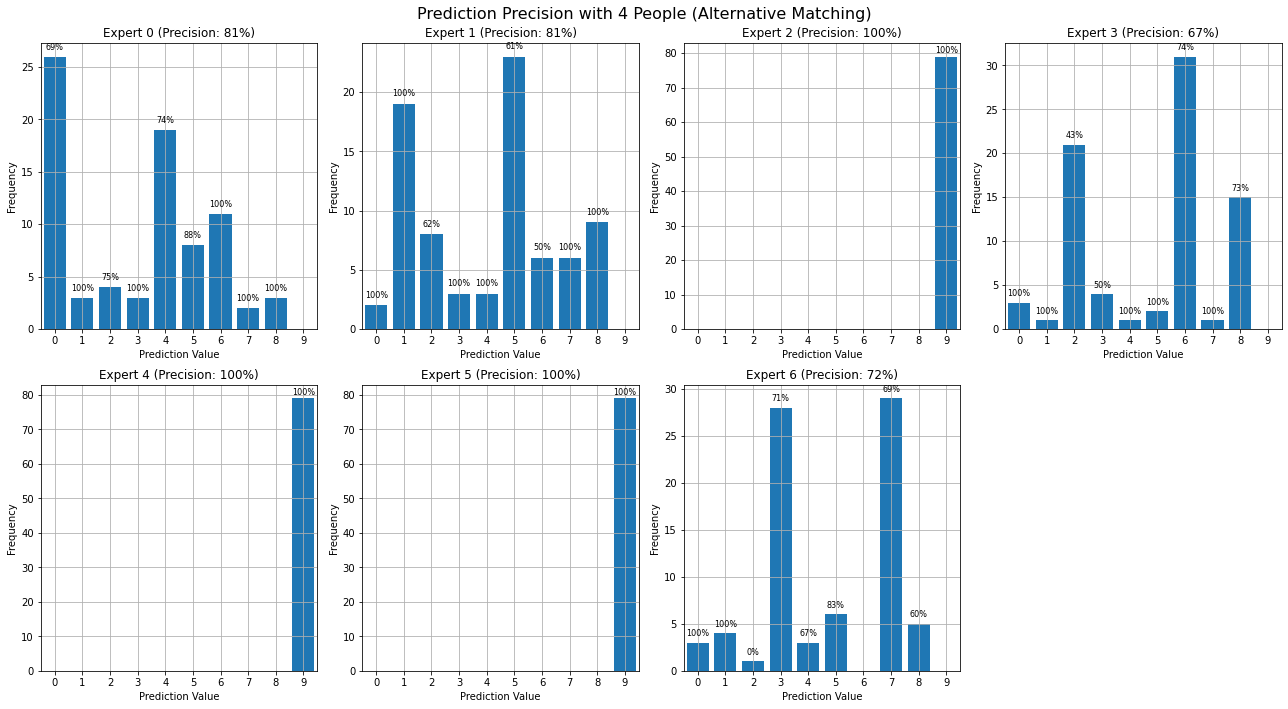

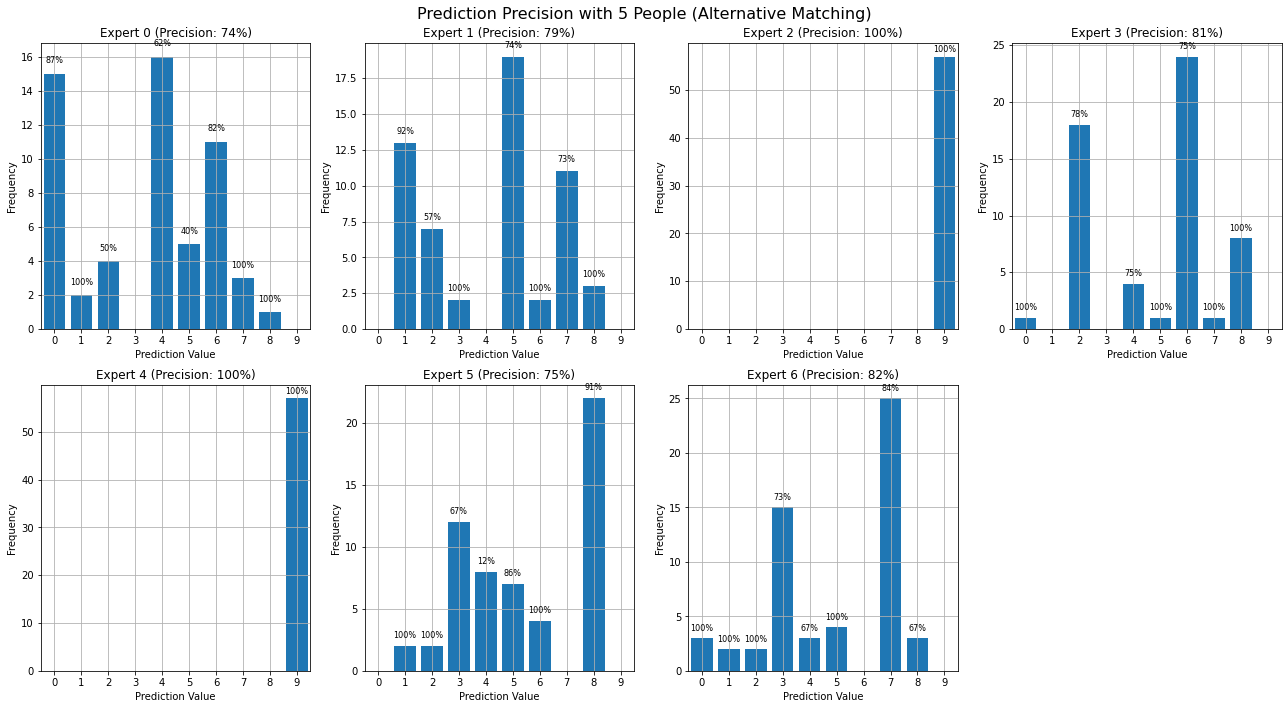

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Calculate the correct precision by accounting for permutations
def calculate_precision_with_matching(predictions, true_labels):
    num_instances = len(predictions)
    precision_by_class = {cls: {'correct': 0, 'total': 0} for cls in range(10)}
    
    for i in range(num_instances):
        pred_row = predictions[i]
        true_row = true_labels[i]
        
        # Count occurrences of each class in predictions and true labels
        pred_counts = Counter(pred_row)
        true_counts = Counter(true_row)
        
        # For each class, calculate precision
        for cls in range(10):
            pred_count = pred_counts.get(cls, 0)
            true_count = true_counts.get(cls, 0)
            
            # The number of correct predictions is the minimum of predicted and true counts
            correct = min(pred_count, true_count)
            
            precision_by_class[cls]['correct'] += correct
            precision_by_class[cls]['total'] += pred_count
    
    # Calculate precision for each class
    precision = {}
    for cls, counts in precision_by_class.items():
        if counts['total'] > 0:
            precision[cls] = counts['correct'] / counts['total']
        else:
            precision[cls] = None  # No predictions for this class
    
    return precision

# Step 1: Determine people count for each instance
def count_people(predictions_row):
    # Count how many non-9 values (activities) are in the row
    return sum(1 for pred in predictions_row if pred != 9)

# Calculate people count for each instance
people_counts = [count_people(row) for row in predict_test_y_last]

# Group instances by people count
instances_by_count = defaultdict(list)
for idx, count in enumerate(people_counts):
    instances_by_count[count].append(idx)

# Create visualization for each people count
unique_counts = sorted(instances_by_count.keys())
num_queries = 7

for people_count in unique_counts:
    if len(instances_by_count[people_count]) < 5:  # Skip if too few samples
        continue
        
    # Get indices of instances with this people count
    indices = instances_by_count[people_count]
    
    # Create subplots
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()
    
    for query_idx in range(num_queries):
        ax = axes[query_idx]
        
        # Get predictions for this query and people count
        predictions = predict_test_y_last[indices, query_idx]
        
        # Create histogram of predictions
        n, bins, patches = ax.hist(predictions, bins=range(11), align='left', rwidth=0.8)
        
        # Get all predictions and true labels for instances with this people count
        all_predictions = predict_test_y_last[indices]
        all_true_labels = y_test[indices]
        
        # Calculate precision by class considering permutations
        # For each class that this expert predicts, what's the precision?
        expert_predictions = []
        for i, idx in enumerate(indices):
            # Create a row where only this expert's prediction is present, rest are -1
            row = [-1] * num_queries
            row[query_idx] = all_predictions[i, query_idx]
            expert_predictions.append(row)
        
        precision = calculate_precision_with_matching(expert_predictions, all_true_labels)
        
        # Add precision percentage on top of each bar
        for cls in range(10):
            bar_height = n[cls]
            if bar_height > 0 and precision[cls] is not None:  # Only add text if the bar exists and precision is calculated
                ax.text(cls, bar_height + 0.5, f"{precision[cls]:.0%}", 
                        ha='center', va='bottom', fontsize=8)
        
        ax.set_xticks(range(10))
        ax.set_xlim(-0.5, 9.5)
        ax.set_xlabel('Prediction Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Expert {query_idx}')
        ax.grid(True)
    
    # Remove any unused subplots
    for idx in range(num_queries, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.suptitle(f'Prediction Precision with {people_count} People in Room (Matching Algorithm)', fontsize=16)
    plt.subplots_adjust(top=0.93)
    plt.show()

# Create an alternative version with a different matching approach if needed
def calculate_matching_precision_alternative(predictions, true_labels, expert_idx):
    """
    Alternative approach: For each instance, check if the expert's prediction
    appears anywhere in the true labels row
    """
    correct = 0
    total = 0
    
    precision_by_class = {cls: {'correct': 0, 'total': 0} for cls in range(10)}
    
    for i in range(len(predictions)):
        pred = predictions[i, expert_idx]
        true_row = true_labels[i]
        
        # Count this prediction
        precision_by_class[pred]['total'] += 1
        total += 1
        
        # If this prediction appears anywhere in the true labels, it's correct
        if pred in true_row:
            precision_by_class[pred]['correct'] += 1
            correct += 1
    
    # Calculate precision for each class
    precision = {}
    for cls, counts in precision_by_class.items():
        if counts['total'] > 0:
            precision[cls] = counts['correct'] / counts['total']
        else:
            precision[cls] = None
    
    overall_precision = correct / total if total > 0 else 0
    
    return precision, overall_precision

# You can uncomment the code below to use the alternative matching approach

for people_count in unique_counts:
    if len(instances_by_count[people_count]) < 5:
        continue
        
    indices = instances_by_count[people_count]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()
    
    for query_idx in range(num_queries):
        ax = axes[query_idx]
        
        # Get all predictions and true labels for instances with this people count
        all_predictions = predict_test_y_last[indices]
        all_true_labels = y_test[indices]
        
        # Calculate precision with alternative matching
        precision, overall = calculate_matching_precision_alternative(
            all_predictions, all_true_labels, query_idx)
        
        # Create histogram
        n, bins, patches = ax.hist(all_predictions[:, query_idx], bins=range(11), align='left', rwidth=0.8)
        
        # Add precision percentage on top of each bar
        for cls in range(10):
            bar_height = n[cls]
            if bar_height > 0 and precision[cls] is not None:
                ax.text(cls, bar_height + 0.5, f"{precision[cls]:.0%}", 
                        ha='center', va='bottom', fontsize=8)
        
        ax.set_xticks(range(10))
        ax.set_xlim(-0.5, 9.5)
        ax.set_xlabel('Prediction Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Expert {query_idx} (Precision: {overall:.0%})')
        ax.grid(True)
    
    for idx in range(num_queries, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.suptitle(f'Prediction Precision with {people_count} People (Alternative Matching)', fontsize=16)
    plt.subplots_adjust(top=0.93)
    plt.show()


We can see also experts are used differently depend on how many people are inside the room.

Looking at the plots we can see that when we have 4 people inside the room Expert 0 specialize in activity 0 and 4, and for 5 people inside the room we observe the same pattern

In [11]:
y_pred = predict_test_y[-1]
y_pred = np.eye(10)[y_pred.argmax(axis=2)].sum(axis=1)[:, :-1]
y_test = data_test_y.sum(axis=1)[:, :-1]
y_train = data_train_y.sum(axis=1)[:, :-1]



In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Find indices where only one person is present in the true labels
# This means sum of the row is 1
single_person_indices = np.where(np.sum(y_test, axis=1) == 1)[0]

if len(single_person_indices) == 0:
    print("No single person scenarios found in the data")
else:
    print(f"Found {len(single_person_indices)} single person scenarios in the test data")
    
    # Extract the corresponding true and predicted labels
    y_true_single = y_test[single_person_indices]
    y_pred_single = y_pred[single_person_indices]
    
    # Convert multi-hot encoding to activity classes
    # For each row, find the index of the non-zero element
    y_true_classes = np.argmax(y_true_single, axis=1)
    
    # For predictions, we'll take the highest value
    y_pred_classes = np.argmax(y_pred_single, axis=1)
    
    # Calculate overall accuracy for single person scenarios
    accuracy = accuracy_score(y_true_classes, y_pred_classes)
    
    # Calculate per-class metrics
    precision = precision_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    recall = recall_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    f1 = f1_score(y_true_classes, y_pred_classes, average='macro', zero_division=0)
    
    print(f"Overall accuracy for single person activities: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

Found 123 single person scenarios in the test data
Overall accuracy for single person activities: 0.6667
Precision (macro): 0.6656
Recall (macro): 0.6553
F1 Score (macro): 0.6438


In [13]:
# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Get detailed classification report
report = classification_report(y_true_classes, y_pred_classes)

# Calculate activity-specific metrics
activity_counts = np.bincount(y_true_classes)
activity_correct = np.zeros_like(activity_counts)

for i in range(len(y_true_classes)):
    if y_true_classes[i] == y_pred_classes[i]:
        activity_correct[y_true_classes[i]] += 1

activity_accuracies = np.zeros_like(activity_counts, dtype=float)
for i in range(len(activity_counts)):
    if activity_counts[i] > 0:
        activity_accuracies[i] = activity_correct[i] / activity_counts[i]
    else:
        activity_accuracies[i] = np.nan

# Print classification report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       1.00      0.93      0.96        14
           2       0.33      0.57      0.42         7
           3       0.75      0.38      0.50        16
           4       0.45      0.50      0.48        10
           5       0.60      0.69      0.64        13
           6       0.62      0.50      0.55        16
           7       0.52      0.79      0.63        14
           8       0.82      0.60      0.69        15

    accuracy                           0.67       123
   macro avg       0.67      0.66      0.64       123
weighted avg       0.70      0.67      0.67       123



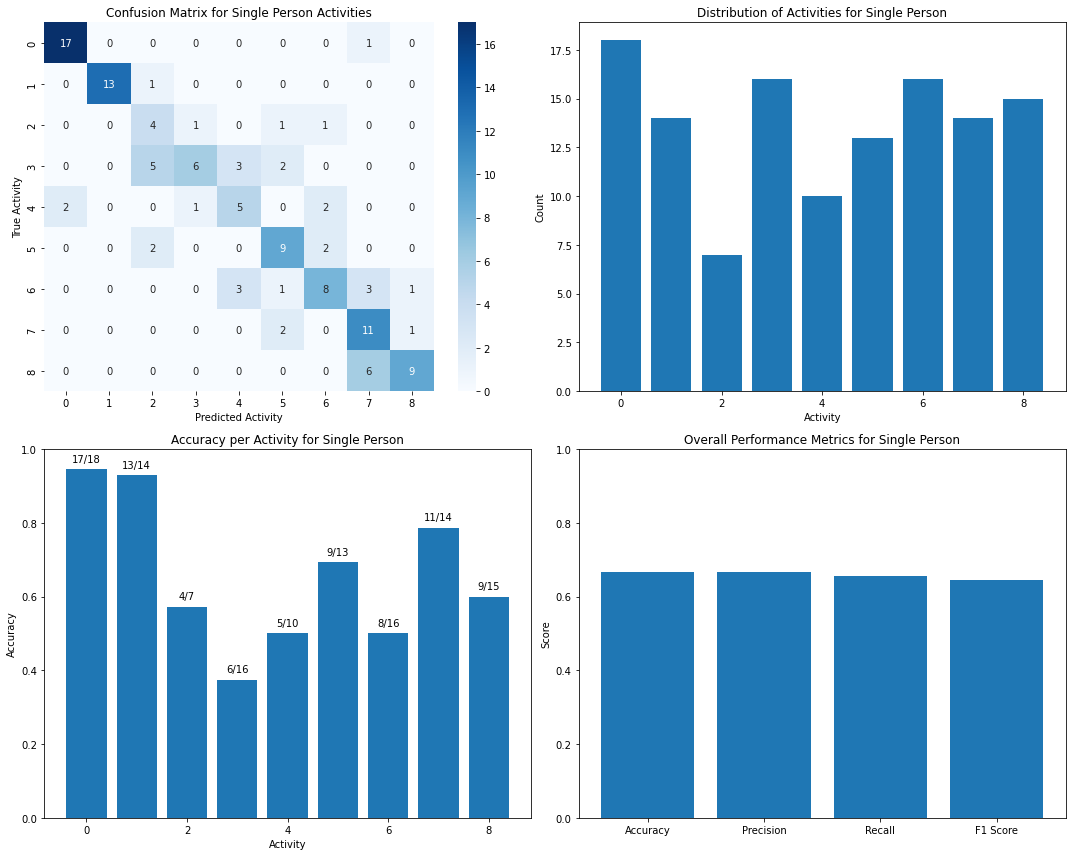

In [14]:
# Create a 2x2 grid of plots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axs[0, 0])
axs[0, 0].set_title("Confusion Matrix for Single Person Activities")
axs[0, 0].set_xlabel("Predicted Activity")
axs[0, 0].set_ylabel("True Activity")

# Plot activity distribution
activity_labels = np.arange(len(activity_counts))
axs[0, 1].bar(activity_labels, activity_counts)
axs[0, 1].set_title("Distribution of Activities for Single Person")
axs[0, 1].set_xlabel("Activity")
axs[0, 1].set_ylabel("Count")

# Plot activity-specific accuracies
ax_acc = axs[1, 0]
ax_acc.bar(activity_labels, activity_accuracies)
ax_acc.set_title("Accuracy per Activity for Single Person")
ax_acc.set_xlabel("Activity")
ax_acc.set_ylabel("Accuracy")
ax_acc.set_ylim(0, 1)

# Add count labels above bars
for i, v in enumerate(activity_counts):
    if v > 0:  # Only show labels for activities that have samples
        acc = activity_accuracies[i]
        correct = activity_correct[i]
        ax_acc.text(i, acc + 0.02, f"{correct}/{v}", ha='center')

# Plot overall metrics
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
metrics_values = [accuracy, precision, recall, f1]
axs[1, 1].bar(metrics_names, metrics_values)
axs[1, 1].set_title("Overall Performance Metrics for Single Person")
axs[1, 1].set_ylabel("Score")
axs[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

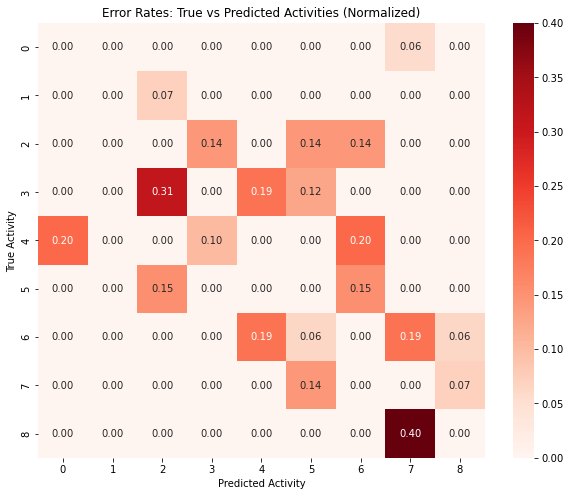

Most common misclassifications (True -> Predicted, Count, Rate):
  Activity 8 -> Activity 7: 6 instances (40.00%)
  Activity 3 -> Activity 2: 5 instances (31.25%)
  Activity 3 -> Activity 4: 3 instances (18.75%)
  Activity 6 -> Activity 4: 3 instances (18.75%)
  Activity 6 -> Activity 7: 3 instances (18.75%)


In [15]:
# Find misclassified instances
misclassified_indices = np.where(y_true_classes != y_pred_classes)[0]

if len(misclassified_indices) == 0:
    print("No misclassifications found!")
else:
    # Extract misclassified instances
    misclassified_true = y_true_classes[misclassified_indices]
    misclassified_pred = y_pred_classes[misclassified_indices]
    
    # Create a matrix to count common misclassifications
    n_activities = len(activity_labels)
    error_matrix = np.zeros((n_activities, n_activities))
    
    for i in range(len(misclassified_true)):
        error_matrix[misclassified_true[i], misclassified_pred[i]] += 1
    
    # Normalize by number of instances per true class
    normalized_error_matrix = np.zeros_like(error_matrix, dtype=float)
    for i in range(n_activities):
        if activity_counts[i] > 0:
            normalized_error_matrix[i, :] = error_matrix[i, :] / activity_counts[i]
    
    # Visualize the error patterns
    plt.figure(figsize=(10, 8))
    sns.heatmap(normalized_error_matrix, annot=True, fmt=".2f", cmap="Reds")
    plt.title("Error Rates: True vs Predicted Activities (Normalized)")
    plt.xlabel("Predicted Activity")
    plt.ylabel("True Activity")
    plt.show()
    
    # Find most common misclassifications
    most_common_errors = []
    for i in range(n_activities):
        for j in range(n_activities):
            if i != j and error_matrix[i, j] > 0:
                most_common_errors.append((i, j, error_matrix[i, j], normalized_error_matrix[i, j]))
    
    most_common_errors.sort(key=lambda x: x[2], reverse=True)
    
    print("Most common misclassifications (True -> Predicted, Count, Rate):")
    for true_act, pred_act, count, rate in most_common_errors[:5]:
        print(f"  Activity {true_act} -> Activity {pred_act}: {int(count)} instances ({rate:.2%})")


===== Training vs Test Distribution Analysis =====
Found 471 single person scenarios in the training data


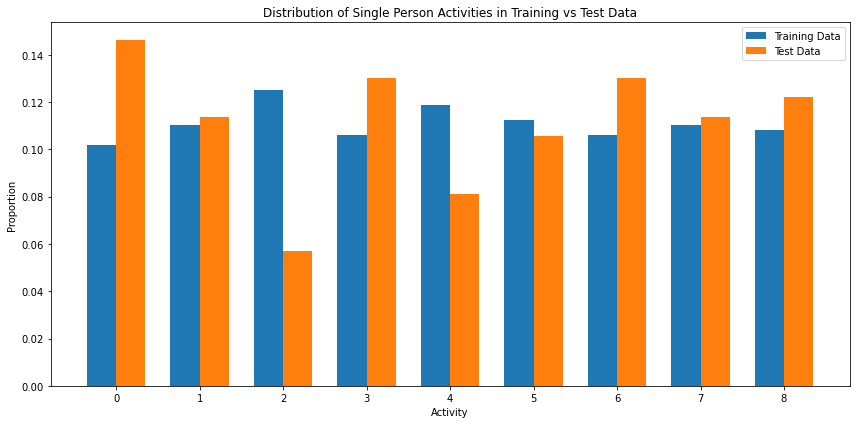

Average absolute difference in activity distribution: 0.0251
The activity distribution is relatively similar between training and test data.


In [16]:
# Only run this cell if y_train is available
try:
    # Check if y_train variable exists
    y_train
    has_train_data = True
except NameError:
    has_train_data = False

if has_train_data:
    print("\n===== Training vs Test Distribution Analysis =====")
    
    # Count single person instances in training data
    train_single_indices = np.where(np.sum(y_train, axis=1) == 1)[0]
    
    if len(train_single_indices) == 0:
        print("No single person scenarios found in training data")
    else:
        print(f"Found {len(train_single_indices)} single person scenarios in the training data")
        
        # Calculate activity distribution in training data
        y_train_single = y_train[train_single_indices]
        y_train_classes = np.argmax(y_train_single, axis=1)
        train_activity_counts = np.bincount(y_train_classes)
        
        test_activity_counts = activity_counts
        
        # Ensure arrays have same length for comparison
        max_len = max(len(train_activity_counts), len(test_activity_counts))
        if len(train_activity_counts) < max_len:
            train_activity_counts = np.pad(train_activity_counts, (0, max_len - len(train_activity_counts)))
        if len(test_activity_counts) < max_len:
            test_activity_counts = np.pad(test_activity_counts, (0, max_len - len(test_activity_counts)))
        
        # Normalize to get distribution
        train_dist = train_activity_counts / np.sum(train_activity_counts) if np.sum(train_activity_counts) > 0 else np.zeros_like(train_activity_counts)
        test_dist = test_activity_counts / np.sum(test_activity_counts) if np.sum(test_activity_counts) > 0 else np.zeros_like(test_activity_counts)
        
        # Plot distribution comparison
        plt.figure(figsize=(12, 6))
        x = np.arange(max_len)
        width = 0.35
        
        plt.bar(x - width/2, train_dist, width, label='Training Data')
        plt.bar(x + width/2, test_dist, width, label='Test Data')
        
        plt.xlabel('Activity')
        plt.ylabel('Proportion')
        plt.title('Distribution of Single Person Activities in Training vs Test Data')
        plt.xticks(x, np.arange(max_len))
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Calculate distribution difference
        dist_diff = np.abs(train_dist - test_dist)
        avg_diff = np.mean(dist_diff)
        
        print(f"Average absolute difference in activity distribution: {avg_diff:.4f}")
        
        if avg_diff > 0.1:
            print("There may be a significant distribution shift between training and test data.")
        else:
            print("The activity distribution is relatively similar between training and test data.")
else:
    print("Training data not available for distribution analysis.")

In [17]:
print("\n===== Summary of Single-Person Activity Recognition Analysis =====")

if 'accuracy' in locals():
    print(f"1. Overall accuracy for single-person activities: {accuracy:.4f}")
    print(f"2. F1 score (macro) for single-person activities: {f1:.4f}")
    
    # Find best and worst performing activities
    best_activity = np.argmax(activity_accuracies) if len(activity_accuracies) > 0 else None
    worst_activity = np.argmin(activity_accuracies) if len(activity_accuracies) > 0 else None
    
    if best_activity is not None:
        print(f"3. Best performing activity: Activity {best_activity} with accuracy {activity_accuracies[best_activity]:.4f}")
    
    if worst_activity is not None and not np.isnan(activity_accuracies[worst_activity]):
        print(f"4. Worst performing activity: Activity {worst_activity} with accuracy {activity_accuracies[worst_activity]:.4f}")
    
    if 'multiple_accuracy' in locals():
        performance_diff = accuracy - multiple_accuracy
        if abs(performance_diff) > 0.1:
            if performance_diff > 0:
                print(f"5. The model performs significantly better on single-person scenarios (by {performance_diff:.4f})")
            else:
                print(f"5. The model performs significantly better on multiple-person scenarios (by {-performance_diff:.4f})")
        else:
            print("5. The model performs similarly on both single and multiple person scenarios")

print("\nPotential next steps for analysis and improvement:")
print("- Investigate specific activities with poor performance")
print("- Check if there are common feature patterns in frequently misclassified activities")
print("- Consider class balancing techniques if some activities are underrepresented")
print("- Evaluate model calibration and threshold adjustments")


===== Summary of Single-Person Activity Recognition Analysis =====
1. Overall accuracy for single-person activities: 0.6667
2. F1 score (macro) for single-person activities: 0.6438
3. Best performing activity: Activity 0 with accuracy 0.9444
4. Worst performing activity: Activity 3 with accuracy 0.3750

Potential next steps for analysis and improvement:
- Investigate specific activities with poor performance
- Check if there are common feature patterns in frequently misclassified activities
- Consider class balancing techniques if some activities are underrepresented
- Evaluate model calibration and threshold adjustments


In [18]:
import pandas as pd 
def count_people(row):
    return int(np.sum(row))

# Get the total number of people in each scenario
people_counts_test = np.array([count_people(row) for row in y_test])
people_counts_pred = np.array([count_people(row) for row in y_pred])

# Create a DataFrame for easier analysis
results_df = pd.DataFrame({
    'true_people': people_counts_test,
    'pred_people': people_counts_pred
})

# Group indices by number of people
indices_by_people = {}
for people_count in range(2, 6):  # 2, 3, 4, 5 people
    indices_by_people[people_count] = np.where(people_counts_test == people_count)[0]
    print(f"Found {len(indices_by_people[people_count])} scenarios with {people_count} people")

# Check if we have enough data for each group
for people_count in range(2, 6):
    if len(indices_by_people[people_count]) < 5:
        print(f"Warning: Very few samples with {people_count} people. Results may not be reliable.")

Found 53 scenarios with 2 people
Found 60 scenarios with 3 people
Found 61 scenarios with 4 people
Found 56 scenarios with 5 people


Overall accuracy in predicting total number of people: 0.8939


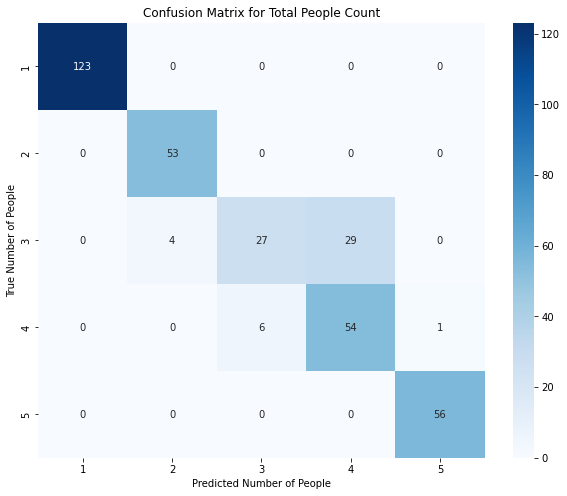

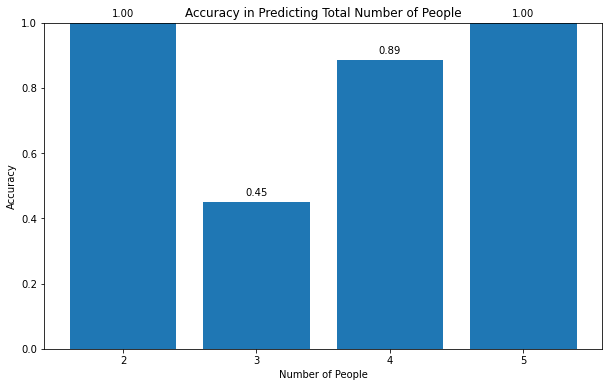

In [19]:
# Calculate overall people count accuracy
people_count_accuracy = np.mean(people_counts_test == people_counts_pred)
print(f"Overall accuracy in predicting total number of people: {people_count_accuracy:.4f}")

# Confusion matrix for people count
people_max = max(np.max(people_counts_test), np.max(people_counts_pred))
people_cm = confusion_matrix(
    people_counts_test, 
    people_counts_pred,
    labels=range(1, people_max + 1)
)

plt.figure(figsize=(10, 8))
sns.heatmap(people_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Total People Count")
plt.xlabel("Predicted Number of People")
plt.ylabel("True Number of People")
plt.xticks(np.arange(0.5, people_max+0.5), range(1, people_max+1))
plt.yticks(np.arange(0.5, people_max+0.5), range(1, people_max+1))
plt.show()

# Calculate per-count accuracy
people_accuracies = {}
for people_count in range(2, 6):
    indices = indices_by_people[people_count]
    if len(indices) > 0:
        correct = np.sum(people_counts_test[indices] == people_counts_pred[indices])
        people_accuracies[people_count] = correct / len(indices)
    else:
        people_accuracies[people_count] = np.nan

# Plot people count accuracies
plt.figure(figsize=(10, 6))
counts = list(people_accuracies.keys())
accuracies = list(people_accuracies.values())
plt.bar(counts, accuracies)
plt.title("Accuracy in Predicting Total Number of People")
plt.xlabel("Number of People")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(counts)
for i, v in enumerate(accuracies):
    if not np.isnan(v):
        plt.text(counts[i], v + 0.02, f"{v:.2f}", ha='center')
plt.show()

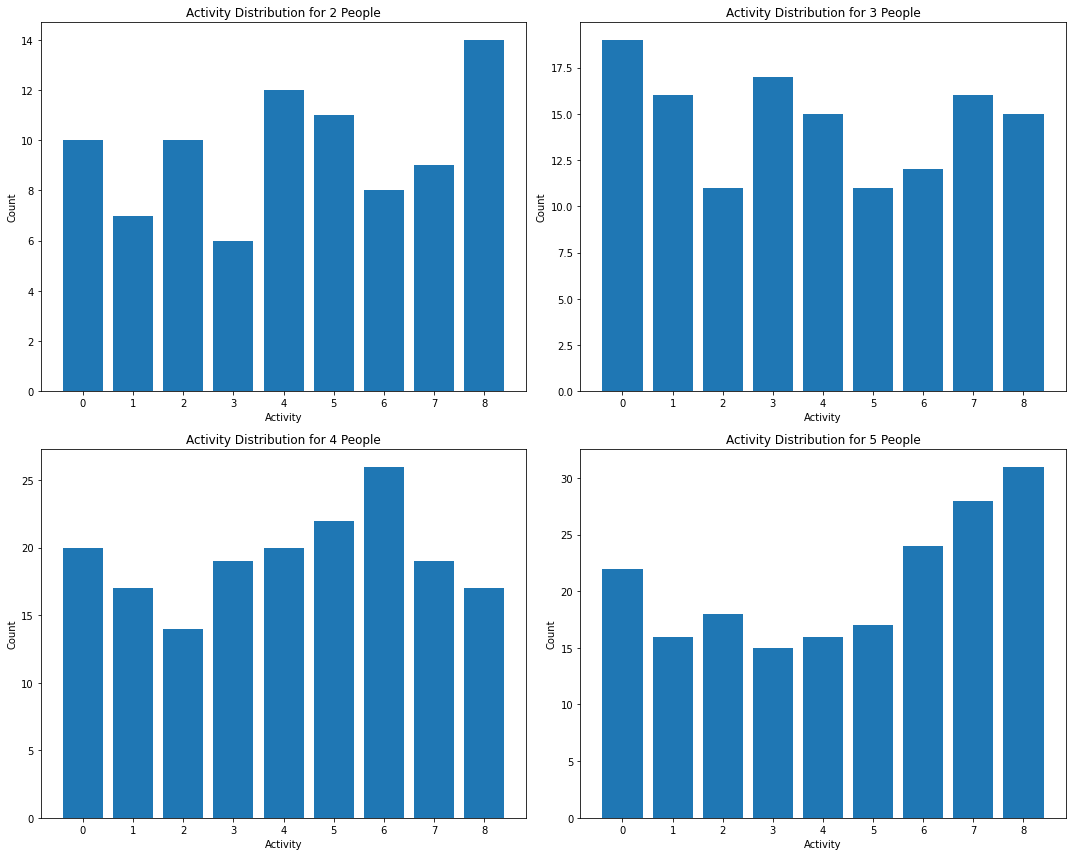

In [20]:
# Create a figure with subplots for each people count
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

# For each people count (2-5), show activity distribution
for i, people_count in enumerate(range(2, 6)):
    indices = indices_by_people[people_count]
    if len(indices) > 0:
        # Count occurrences of each activity
        activity_counts = np.zeros(n_activities)
        for idx in indices:
            for activity in range(n_activities):
                if y_test[idx, activity] > 0:
                    activity_counts[activity] += 1
        
        # Plot distribution
        axs[i].bar(range(n_activities), activity_counts)
        axs[i].set_title(f"Activity Distribution for {people_count} People")
        axs[i].set_xlabel("Activity")
        axs[i].set_ylabel("Count")
        axs[i].set_xticks(range(n_activities))
    else:
        axs[i].text(0.5, 0.5, f"No data for {people_count} people", 
                  horizontalalignment='center', verticalalignment='center',
                  transform=axs[i].transAxes)

plt.tight_layout()
plt.show()

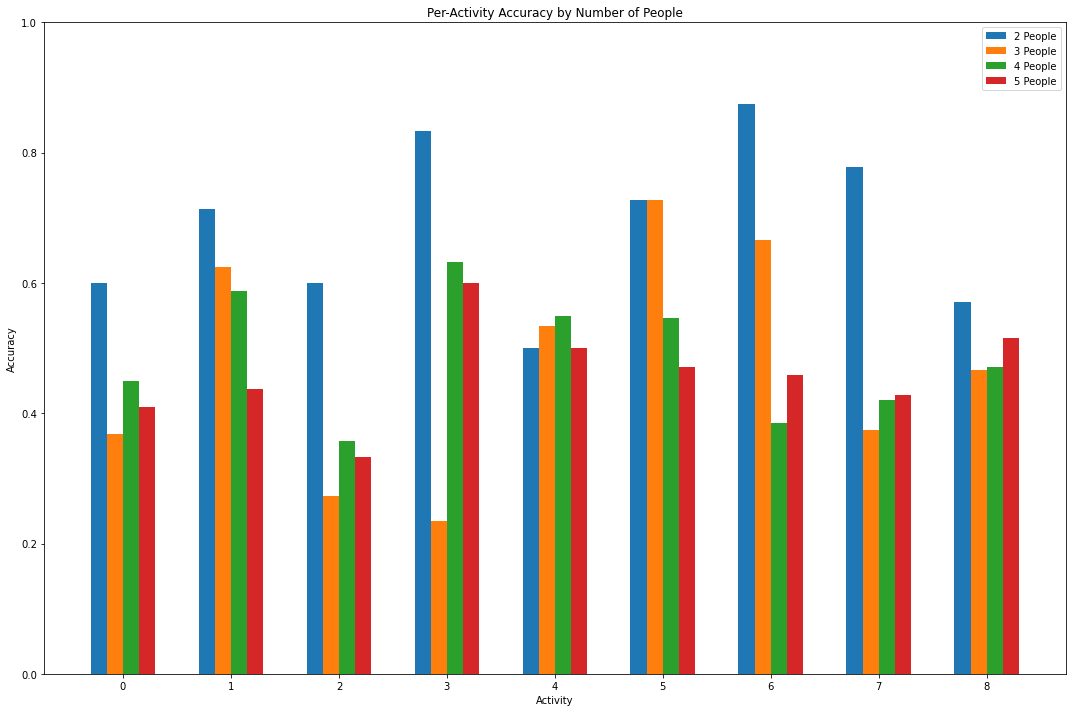

Summary of Activity Accuracies by People Count:
------------------------------------------------------------
Activity | 2 People | 3 People | 4 People | 5 People
------------------------------------------------------------
       0 | 0.60 ( 10) | 0.37 ( 19) | 0.45 ( 20) | 0.41 ( 22) |
       1 | 0.71 (  7) | 0.62 ( 16) | 0.59 ( 17) | 0.44 ( 16) |
       2 | 0.60 ( 10) | 0.27 ( 11) | 0.36 ( 14) | 0.33 ( 18) |
       3 | 0.83 (  6) | 0.24 ( 17) | 0.63 ( 19) | 0.60 ( 15) |
       4 | 0.50 ( 12) | 0.53 ( 15) | 0.55 ( 20) | 0.50 ( 16) |
       5 | 0.73 ( 11) | 0.73 ( 11) | 0.55 ( 22) | 0.47 ( 17) |
       6 | 0.88 (  8) | 0.67 ( 12) | 0.38 ( 26) | 0.46 ( 24) |
       7 | 0.78 (  9) | 0.38 ( 16) | 0.42 ( 19) | 0.43 ( 28) |
       8 | 0.57 ( 14) | 0.47 ( 15) | 0.47 ( 17) | 0.52 ( 31) |


In [22]:
# For each people count, calculate per-activity accuracy
activity_accuracies = {}

for people_count in range(2, 6):
    indices = indices_by_people[people_count]
    if len(indices) > 0:
        # Initialize counters for each activity
        correct_count = np.zeros(n_activities)
        total_count = np.zeros(n_activities)
        
        # Calculate accuracy for correctly predicting number of people per activity
        for idx in indices:
            for activity in range(n_activities):
                if y_test[idx, activity] > 0:  # If this activity is happening
                    total_count[activity] += 1
                    if y_pred[idx, activity] == y_test[idx, activity]:  # Correct count
                        correct_count[activity] += 1
        
        # Calculate accuracy for each activity
        activity_acc = np.zeros(n_activities)
        for activity in range(n_activities):
            if total_count[activity] > 0:
                activity_acc[activity] = correct_count[activity] / total_count[activity]
            else:
                activity_acc[activity] = np.nan
        
        activity_accuracies[people_count] = {
            'accuracy': activity_acc,
            'correct': correct_count,
            'total': total_count
        }

# Plot activity accuracies for each people count
plt.figure(figsize=(15, 10))

# For each people count, create a grouped bar chart
bar_width = 0.15
activity_indices = np.arange(n_activities)

for i, people_count in enumerate(range(2, 6)):
    if people_count in activity_accuracies:
        plt.bar(
            activity_indices + i * bar_width - bar_width * 1.5, 
            activity_accuracies[people_count]['accuracy'], 
            width=bar_width, 
            label=f"{people_count} People"
        )

plt.xlabel('Activity')
plt.ylabel('Accuracy')
plt.title('Per-Activity Accuracy by Number of People')
plt.xticks(activity_indices, activity_indices)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print a summary table
print("Summary of Activity Accuracies by People Count:")
print("-" * 60)
print("Activity | 2 People | 3 People | 4 People | 5 People")
print("-" * 60)

for activity in range(n_activities):
    row = f"{activity:8} |"
    for people_count in range(2, 6):
        if people_count in activity_accuracies and not np.isnan(activity_accuracies[people_count]['accuracy'][activity]):
            acc = activity_accuracies[people_count]['accuracy'][activity]
            count = activity_accuracies[people_count]['total'][activity]
            row += f" {acc:.2f} ({int(count):3d}) |"
        else:
            row += " ------ |"
    print(row)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Ensure you have these libraries installed:
# !pip install numpy matplotlib seaborn scikit-learn pandas
def calculate_scores(y_true, y_pred):
    """
    Calculate all performance metrics for the predictions
    Args:
        y_true: numpy array of ground truth values
        y_pred: numpy array of predicted values
    Returns:
        Dictionary containing all performance metrics
    """
    # Calculate basic metrics
    absolute_diff = np.abs(y_true - y_pred)
    
    # Calculate TP, TN, FP, FN
    tp = np.minimum(y_true, y_pred)
    tn = np.where(np.maximum(y_true, y_pred) == 0, 1, 0)
    fp = np.maximum(0, y_pred - y_true) # Extra predictions
    fn = np.maximum(0, y_true - y_pred)  # Missed objects
    
    # Calculate per-activity metrics
    tp_per_activity = tp.sum(axis=0)
    tn_per_activity = tn.sum(axis=0)
    fp_per_activity = fp.sum(axis=0)
    fn_per_activity = fn.sum(axis=0)
    
    # Calculate precision, recall, f1-score
    precision_ = np.where((tp_per_activity + fp_per_activity) > 0, 
                         tp_per_activity / (tp_per_activity + fp_per_activity + 1e-6), 0)
    recall_ = np.where((tp_per_activity + fn_per_activity) > 0,
                      tp_per_activity / (tp_per_activity + fn_per_activity + 1e-6), 0)
    f1_score_ = np.where((precision_ + recall_) > 0,
                        2 * (precision_ * recall_) / (precision_ + recall_ + 1e-6), 0)
    accuracy_ = (tp_per_activity + tn_per_activity) / (tp_per_activity + fn_per_activity + tn_per_activity + fp_per_activity)
    
    # Calculate perfect predictions
    perfect_prediction_mask = np.all(absolute_diff == 0, axis=1)
    perfect_predictions = np.sum(perfect_prediction_mask)
    batch_size = len(y_true)
    perfect_prediction_percentage = (perfect_predictions / batch_size) * 100
    
    # Calculate total error
    total_error = np.sum(absolute_diff) / batch_size
    
    # Calculate error per person and counting error
    error_per_person = error_per_number_person(y_pred, y_true)
    counting_error_perPerson = count_error(y_pred, y_true)
    mean_count_error = counting_error_perPerson.mean()
    
    return {
        'total_error': total_error,
        'perfect_prediction_percentage': perfect_prediction_percentage,
        'accuracy': accuracy_.mean(),
        'error_per_person': error_per_person,
        'mean_count_error': mean_count_error,
        'counting_error_perPerson': counting_error_perPerson,
        'precision': precision_.mean(),
        'recall': recall_.mean(),
        'f1_score': f1_score_.mean()
    }

def error_per_number_person(y_pred, y_true):
    """
    Calculate error per person in the scene
    Args:
        y_pred: numpy array of predicted values
        y_true: numpy array of ground truth values
    Returns:
        Average error per person
    """
    absolute_diff = np.abs(y_true - y_pred)
    total_error = np.sum(absolute_diff)
    total_people = np.sum(y_true)
    if total_people > 0:
        return total_error / total_people
    return 0

def count_error(y_pred, y_true):
    """
    Calculate the error in counting the total number of people
    Args:
        y_pred: numpy array of predicted values
        y_true: numpy array of ground truth values
    Returns:
        Array of counting errors for each sample
    """
    true_count = np.sum(y_true, axis=1)
    pred_count = np.sum(y_pred, axis=1)
    return np.abs(true_count - pred_count)

In [23]:
def group_by_person_count(y_true, y_pred):
    """
    Group data by the total number of people in the room.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        
    Returns:
        Dictionary with keys as person counts and values as tuples of (y_true_subset, y_pred_subset, indices)
    """
    # Calculate total people per sample
    people_per_sample = np.sum(y_true, axis=1)
    
    # Group data
    result = {}
    for count in range(1, 6):  # 1 to 5 people
        indices = np.where(people_per_sample == count)[0]
        if len(indices) > 0:
            result[count] = (y_true[indices], y_pred[indices], indices)
    
    return result

# Group our data
grouped_data = group_by_person_count(y_test, y_pred)

# Show how many samples we have for each group
for count, (y_true_group, y_pred_group, indices) in grouped_data.items():
    print(f"Number of samples with {count} {'person' if count==1 else 'people'}: {len(indices)}")

Number of samples with 1 person: 369
Number of samples with 2 people: 159
Number of samples with 3 people: 180
Number of samples with 4 people: 183
Number of samples with 5 people: 168


In [24]:
# Store performance metrics for each group
performance_metrics = {}

# Analyze each group
for count, (y_true_group, y_pred_group, _) in grouped_data.items():
    if len(y_true_group) < 5:  # Skip groups with too few samples
        print(f"Skipping {count} people group due to insufficient samples ({len(y_true_group)})")
        continue
        
    print(f"\n===== Analysis for {count} {'person' if count==1 else 'people'} =====")
    
    # Calculate metrics
    metrics = calculate_scores(y_true_group, y_pred_group)
    performance_metrics[count] = metrics
    
    # Print key metrics
    print(f"Total samples: {len(y_true_group)}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Perfect prediction %: {metrics['perfect_prediction_percentage']:.2f}%")
    print(f"Total error: {metrics['total_error']:.4f}")
    print(f"Error per person: {metrics['error_per_person']:.4f}")
    print(f"Mean count error: {metrics['mean_count_error']:.4f}")


===== Analysis for 1 person =====
Total samples: 369
Precision: 0.3753
Recall: 0.4437
F1 Score: 0.3605
Perfect prediction %: 28.46%
Total error: 2.0136
Error per person: 2.0136
Mean count error: 0.9729

===== Analysis for 2 people =====
Total samples: 159
Precision: 0.5847
Recall: 0.4981
F1 Score: 0.5208
Perfect prediction %: 21.38%
Total error: 1.7925
Error per person: 0.8962
Mean count error: 0.3962

===== Analysis for 3 people =====
Total samples: 180
Precision: 0.5452
Recall: 0.4410
F1 Score: 0.4758
Perfect prediction %: 6.67%
Total error: 2.9000
Error per person: 0.9667
Mean count error: 0.9111

===== Analysis for 4 people =====
Total samples: 183
Precision: 0.6004
Recall: 0.4121
F1 Score: 0.4787
Perfect prediction %: 6.56%
Total error: 3.5301
Error per person: 0.8825
Mean count error: 1.2678

===== Analysis for 5 people =====
Total samples: 168
Precision: 0.6020
Recall: 0.3733
F1 Score: 0.4500
Perfect prediction %: 4.76%
Total error: 4.3869
Error per person: 0.8774
Mean count er

# Analysis of Patterns inside the data

### Geting the data ready

In [25]:
y_pred = predict_test_y[-1]
y_pred = np.eye(10)[y_pred.argmax(axis=2)].sum(axis=1)[:, :-1]
y_test = data_test_y.sum(axis=1)[:, :-1]
y_train = data_train_y.sum(axis=1)[:, :-1]

print(y_train.shape)

(4512, 9)


## Pattern That Exists

In [28]:
unique_patterns, counts = np.unique(y_train, axis=0, return_counts=True)
print(f"Found {len(unique_patterns)} unique patterns in the dataset.")
print("Unique patterns and their counts:")
for pattern, count in zip(unique_patterns, counts):
    print(pattern, ":", count)



Found 207 unique patterns in the dataset.
Unique patterns and their counts:
[0. 0. 0. 0. 0. 0. 0. 0. 0.] : 225
[0. 0. 0. 0. 0. 0. 0. 0. 1.] : 153
[0. 0. 0. 0. 0. 0. 0. 0. 2.] : 27
[0. 0. 0. 0. 0. 0. 0. 0. 3.] : 21
[0. 0. 0. 0. 0. 0. 0. 0. 4.] : 12
[0. 0. 0. 0. 0. 0. 0. 0. 5.] : 6
[0. 0. 0. 0. 0. 0. 0. 1. 0.] : 156
[0. 0. 0. 0. 0. 0. 0. 1. 1.] : 39
[0. 0. 0. 0. 0. 0. 0. 2. 0.] : 18
[0. 0. 0. 0. 0. 0. 0. 2. 1.] : 21
[0. 0. 0. 0. 0. 0. 0. 2. 2.] : 6
[0. 0. 0. 0. 0. 0. 0. 3. 0.] : 18
[0. 0. 0. 0. 0. 0. 0. 3. 1.] : 18
[0. 0. 0. 0. 0. 0. 0. 3. 2.] : 12
[0. 0. 0. 0. 0. 0. 0. 4. 0.] : 12
[0. 0. 0. 0. 0. 0. 0. 4. 1.] : 9
[0. 0. 0. 0. 0. 0. 0. 5. 0.] : 6
[0. 0. 0. 0. 0. 0. 1. 0. 0.] : 150
[0. 0. 0. 0. 0. 0. 1. 0. 1.] : 3
[0. 0. 0. 0. 0. 0. 1. 1. 0.] : 39
[0. 0. 0. 0. 0. 0. 1. 1. 1.] : 12
[0. 0. 0. 0. 0. 0. 2. 0. 0.] : 27
[0. 0. 0. 0. 0. 0. 2. 0. 1.] : 6
[0. 0. 0. 0. 0. 0. 2. 1. 0.] : 24
[0. 0. 0. 0. 0. 0. 2. 1. 1.] : 6
[0. 0. 0. 0. 0. 0. 2. 2. 0.] : 12
[0. 0. 0. 0. 0. 0. 2. 2. 1.] : 15
[0. 0. 0.

## Generate all theoretical patterns

In [31]:
# --- 2. Generate all theoretical patterns ---
# We need to generate all 9-dimensional nonnegative integer vectors whose elements sum to k
# for any k from 0 to 5.
def generate_compositions(n, k):
    """
    Generate all n-length tuples of nonnegative integers that sum to k.
    """
    if n == 1:
        yield (k,)
    else:
        for i in range(k + 1):
            for comp in generate_compositions(n - 1, k - i):
                yield (i,) + comp

theoretical_patterns = []
for k in range(6):  # k from 0 to 5 inclusive
    theoretical_patterns.extend(list(generate_compositions(9, k)))

print(f"\nTotal theoretical patterns (should be 2002): {len(theoretical_patterns)}")



Total theoretical patterns (should be 2002): 2002


## Determine which theoretical patterns are missing in the dataset

In [32]:
# --- 3. Determine which theoretical patterns are missing in the dataset ---
# Convert unique dataset patterns into a set of tuples for fast membership testing.
unique_dataset_set = set(tuple(row) for row in unique_patterns)
theoretical_set = set(theoretical_patterns)

missing_patterns = theoretical_set - unique_dataset_set
print(f"\nNumber of theoretical patterns NOT present in the dataset: {len(missing_patterns)}")

if missing_patterns:
    print("\nThe missing patterns are:")
    for pat in sorted(missing_patterns):
        print(pat)
else:
    print("All theoretical patterns are present in the dataset.")


Number of theoretical patterns NOT present in the dataset: 1795

The missing patterns are:
(0, 0, 0, 0, 0, 0, 0, 1, 2)
(0, 0, 0, 0, 0, 0, 0, 1, 3)
(0, 0, 0, 0, 0, 0, 0, 1, 4)
(0, 0, 0, 0, 0, 0, 0, 2, 3)
(0, 0, 0, 0, 0, 0, 1, 0, 2)
(0, 0, 0, 0, 0, 0, 1, 0, 3)
(0, 0, 0, 0, 0, 0, 1, 0, 4)
(0, 0, 0, 0, 0, 0, 1, 1, 2)
(0, 0, 0, 0, 0, 0, 1, 1, 3)
(0, 0, 0, 0, 0, 0, 1, 2, 0)
(0, 0, 0, 0, 0, 0, 1, 2, 1)
(0, 0, 0, 0, 0, 0, 1, 2, 2)
(0, 0, 0, 0, 0, 0, 1, 3, 0)
(0, 0, 0, 0, 0, 0, 1, 3, 1)
(0, 0, 0, 0, 0, 0, 1, 4, 0)
(0, 0, 0, 0, 0, 0, 2, 0, 2)
(0, 0, 0, 0, 0, 0, 2, 0, 3)
(0, 0, 0, 0, 0, 0, 2, 1, 2)
(0, 0, 0, 0, 0, 0, 2, 3, 0)
(0, 0, 0, 0, 0, 0, 3, 0, 1)
(0, 0, 0, 0, 0, 0, 3, 0, 2)
(0, 0, 0, 0, 0, 0, 3, 1, 1)
(0, 0, 0, 0, 0, 0, 4, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 1)
(0, 0, 0, 0, 0, 1, 0, 0, 2)
(0, 0, 0, 0, 0, 1, 0, 0, 3)
(0, 0, 0, 0, 0, 1, 0, 0, 4)
(0, 0, 0, 0, 0, 1, 0, 1, 1)
(0, 0, 0, 0, 0, 1, 0, 1, 2)
(0, 0, 0, 0, 0, 1, 0, 1, 3)
(0, 0, 0, 0, 0, 1, 0, 2, 0)
(0, 0, 0, 0, 0, 1, 0, 2, 1)
(0, 0, 0, 0,

## Summary 

Number of unique instances in the dataset: 207
Total instances in the dataset: 4512
Number of theoretically possible instances: 2002
Verification using formula: Σ(k=0 to 5) C(8+k,k) = 2002
Number of missing instances: 1795

Top 60 most common instances in the dataset:
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 225 occurrences
(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 177 occurrences
(0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 168 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 159 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 156 occurrences
(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 156 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 153 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 150 occurrences
(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 150 occurrences
(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 144 occurrences
(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0): 45 occurrences
(0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0

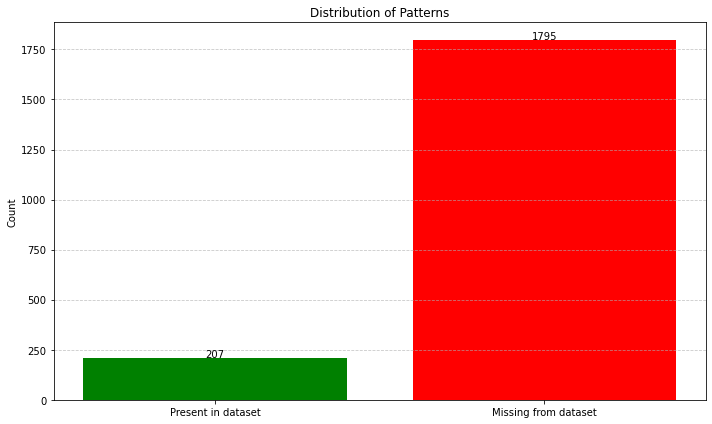


Distribution of sums in the dataset:
Sum = 0: 1 instances
Sum = 1: 9 instances
Sum = 2: 36 instances
Sum = 3: 54 instances
Sum = 4: 63 instances
Sum = 5: 44 instances

Distribution of sums in missing patterns:
Sum = 0: 0 instances
Sum = 1: 0 instances
Sum = 2: 9 instances
Sum = 3: 111 instances
Sum = 4: 432 instances
Sum = 5: 1243 instances

Dataset covers 10.34% of all theoretically possible patterns


In [34]:
import numpy as np
from collections import Counter
import itertools
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Function to generate all possible instances based on the constraints
def generate_all_possible_instances():
    result = []
    
    # For each possible sum from 0 to 5
    for total_sum in range(6):
        # Generate all ways to distribute total_sum objects into 9 bins
        for combination in itertools.combinations_with_replacement(range(9), total_sum):
            # Initialize an instance with all zeros
            instance = [0] * 9
            
            # Increment the appropriate positions based on the combination
            for pos in combination:
                instance[pos] += 1
                
            # Add the instance to our result
            result.append(tuple(instance))
    
    return set(result)

# Convert y_train instances to tuples for counting
y_train_tuples = [tuple(row) for row in y_train]
unique_counts = Counter(y_train_tuples)
unique_instances_set = set(unique_counts.keys())

# Display basic statistics
print(f"Number of unique instances in the dataset: {len(unique_counts)}")
print(f"Total instances in the dataset: {len(y_train_tuples)}")

# Generate all theoretically possible instances
all_possible_instances = generate_all_possible_instances()
print(f"Number of theoretically possible instances: {len(all_possible_instances)}")

# Verify the theoretical count using the formula
theoretical_count = sum(
    [np.math.comb(8+k, k) for k in range(6)]
)
print(f"Verification using formula: Σ(k=0 to 5) C(8+k,k) = {theoretical_count}")

# Find instances that are theoretically possible but not in the dataset
missing_instances = list(all_possible_instances - unique_instances_set)
print(f"Number of missing instances: {len(missing_instances)}")

# Display some examples of the most common instances in the dataset
print("\nTop 60 most common instances in the dataset:")
for instance, count in unique_counts.most_common(60):
    print(f"{instance}: {count} occurrences")

# Display some examples of missing instances
print("\nSome examples of missing instances:")
for instance in list(missing_instances)[:60]:
    print(instance)

# Visualize the distribution of unique instances vs missing instances
plt.figure(figsize=(10, 6))
plt.bar(['Present in dataset', 'Missing from dataset'], 
        [len(unique_instances_set), len(missing_instances)],
        color=['green', 'red'])
plt.title('Distribution of Patterns')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate([len(unique_instances_set), len(missing_instances)]):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

# Analyze the distribution of sums in present vs missing instances
def get_sum_distribution(instances):
    sums = [sum(instance) for instance in instances]
    return Counter(sums)

present_sums = get_sum_distribution(unique_instances_set)
missing_sums = get_sum_distribution(missing_instances)

print("\nDistribution of sums in the dataset:")
for sum_val in range(6):
    print(f"Sum = {sum_val}: {present_sums.get(sum_val, 0)} instances")

print("\nDistribution of sums in missing patterns:")
for sum_val in range(6):
    print(f"Sum = {sum_val}: {missing_sums.get(sum_val, 0)} instances")

# Calculate coverage percentage
coverage_percentage = (len(unique_instances_set) / len(all_possible_instances)) * 100
print(f"\nDataset covers {coverage_percentage:.2f}% of all theoretically possible patterns")

In [42]:
print("\nTop 60 most common instances in the dataset:")
for instance, count in unique_counts.most_common(140):
    if sum(instance) !=2:
        continue
    print(f"{instance}: {int(count/3 * 2)} occurrences")




Top 60 most common instances in the dataset:
(0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0): 30 occurrences
(0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 28 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0): 26 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0): 26 occurrences
(1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 26 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0): 24 occurrences
(0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 22 occurrences
(0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0): 22 occurrences
(2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 22 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0): 20 occurrences
(0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0): 20 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0): 18 occurrences
(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 18 occurrences
(0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 18 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0): 18 occurrences
(0.0, 0.0, 0.0, 0.0, 2.0

In [44]:
print("\nTop  common instances in the dataset:")
for instance, count in unique_counts.most_common(202):
    if sum(instance) !=3:
        continue
    print(f"{instance}: {int(count/3 * 2)} occurrences")




Top  common instances in the dataset:
(0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 16 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0): 16 occurrences
(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0): 16 occurrences
(0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0): 16 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, 0.0): 14 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0): 14 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0): 14 occurrences
(0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 14 occurrences
(0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0): 14 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 0.0): 12 occurrences
(0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 12 occurrences
(2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 12 occurrences
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0): 12 occurrences
(0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0): 10 occurrences
(0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 10 occurrences
(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 

## Multi User Analysis

#### Grouping the data

In [25]:
def group_by_person_count(y_true, y_pred):
    """
    Group data by the total number of people in the room.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        
    Returns:
        Dictionary with keys as person counts and values as tuples of (y_true_subset, y_pred_subset, indices)
    """
    # Calculate total people per sample
    people_per_sample = np.sum(y_true, axis=1)
    
    # Group data
    result = {}
    for count in range(1, 6):  # 1 to 5 people
        indices = np.where(people_per_sample == count)[0]
        if len(indices) > 0:
            result[count] = (y_true[indices], y_pred[indices], indices)
    
    return result

# Group our data
grouped_data = group_by_person_count(y_test, y_pred)

# Show how many samples we have for each group
for count, (y_true_group, y_pred_group, indices) in grouped_data.items():
    print(f"Number of samples with {count} {'person' if count==1 else 'people'}: {len(indices)}")

Number of samples with 1 person: 123
Number of samples with 2 people: 53
Number of samples with 3 people: 60
Number of samples with 4 people: 61
Number of samples with 5 people: 56


In [30]:
### Store performance metrics for each group
performance_metrics = {}

# Analyze each group
for count, (y_true_group, y_pred_group, _) in grouped_data.items():
    if len(y_true_group) < 5:  # Skip groups with too few samples
        print(f"Skipping {count} people group due to insufficient samples ({len(y_true_group)})")
        continue
        
    print(f"\n===== Analysis for {count} {'person' if count==1 else 'people'} =====")
    
    # Calculate metrics
    metrics = calculate_scores(y_true_group, y_pred_group)
    performance_metrics[count] = metrics
    
    # Print key metrics
    print(f"Total samples: {len(y_true_group)}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Perfect prediction %: {metrics['perfect_prediction_percentage']:.2f}%")
    print(f"Total error: {metrics['total_error']:.4f}")
    print(f"Mean count error: {metrics['mean_count_error']:.4f}")


===== Analysis for 1 person =====
Total samples: 123
Precision: 0.6656
Recall: 0.6553
F1 Score: 0.6438
Perfect prediction %: 66.67%
Total error: 0.6667
Mean count error: 0.0000

===== Analysis for 2 people =====
Total samples: 53
Precision: 0.7471
Recall: 0.7387
F1 Score: 0.7258
Perfect prediction %: 54.72%
Total error: 1.0943
Mean count error: 0.0000

===== Analysis for 3 people =====
Total samples: 60
Precision: 0.5972
Recall: 0.6772
F1 Score: 0.6249
Perfect prediction %: 13.33%
Total error: 2.3500
Mean count error: 0.5500

===== Analysis for 4 people =====
Total samples: 61
Precision: 0.7163
Recall: 0.6962
F1 Score: 0.7036
Perfect prediction %: 14.75%
Total error: 2.3115
Mean count error: 0.1148

===== Analysis for 5 people =====
Total samples: 56
Precision: 0.6669
Recall: 0.6771
F1 Score: 0.6648
Perfect prediction %: 16.07%
Total error: 3.2857
Mean count error: 0.0000


In [35]:
performance_metrics.keys()

dict_keys([1, 2, 3, 4, 5])

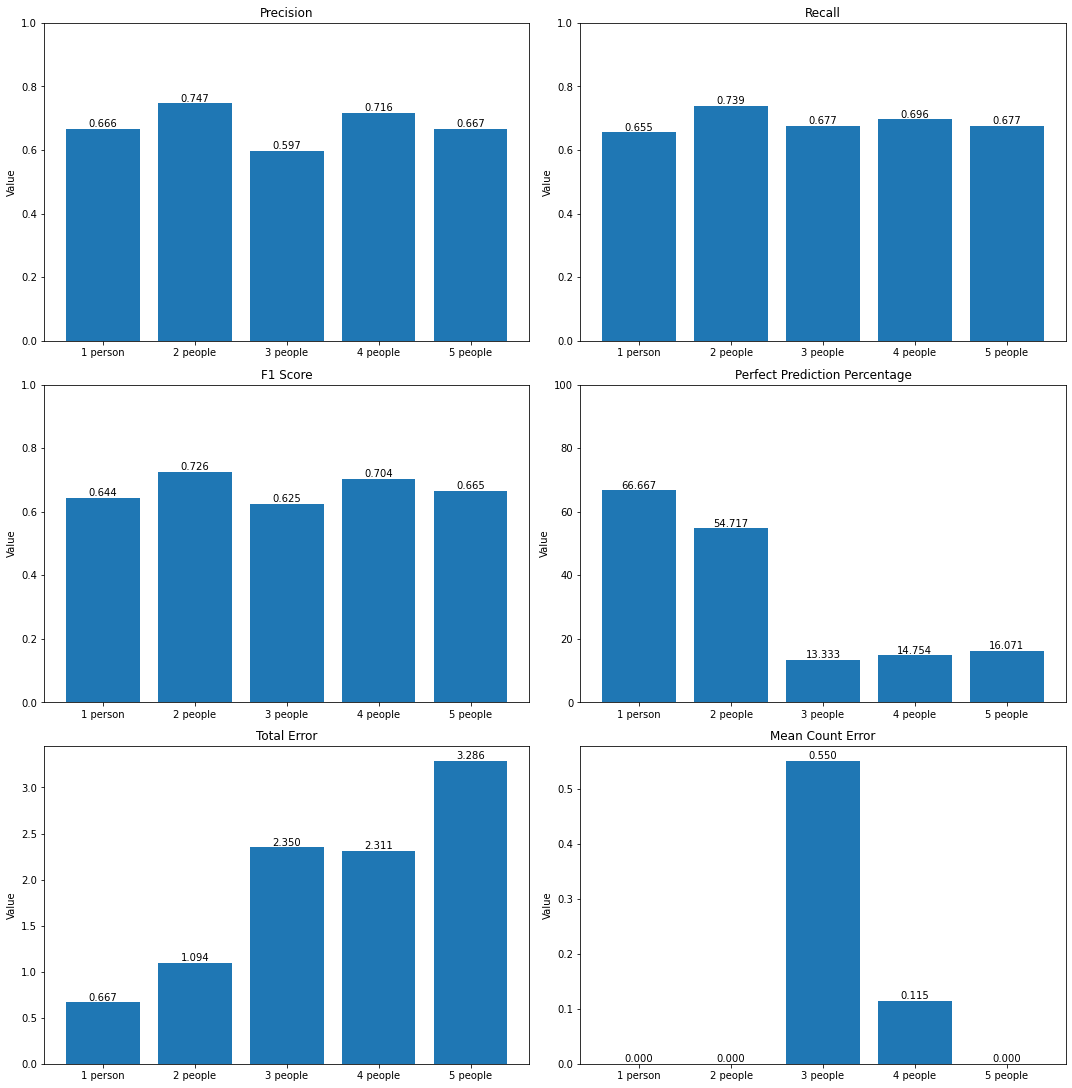

In [36]:
# Extract metrics for comparison
person_counts = sorted(performance_metrics.keys())
metrics_to_plot = ['precision', 'recall', 'f1_score', 'perfect_prediction_percentage', 
                   'total_error', 'mean_count_error']

# Create a figure for comparing metrics
plt.figure(figsize=(15, 20))

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(4, 2, i+1)
    
    values = [performance_metrics[count][metric] for count in person_counts]
    plt.bar([f"{count} {'person' if count==1 else 'people'}" for count in person_counts], values)
    
    plt.title(f"{metric.replace('_', ' ').title()}")
    plt.ylabel("Value")
    
    # Add value labels on top of bars
    for j, v in enumerate(values):
        plt.text(j, v, f"{v:.3f}", ha='center', va='bottom')
    
    # Set y-limit for percentage metrics
    if metric == 'perfect_prediction_percentage':
        plt.ylim(0, 100)
    elif metric in ['precision', 'recall', 'f1_score']:
        plt.ylim(0, 1)

plt.tight_layout()
plt.show()

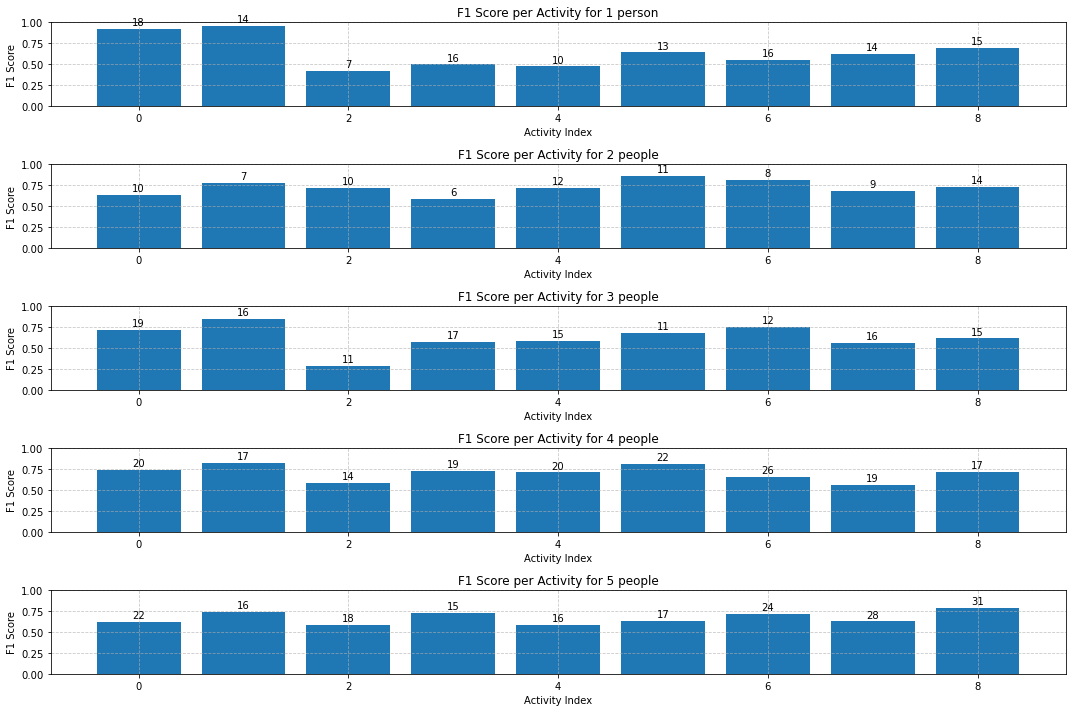

In [43]:
# Let's analyze which activities are performed correctly for each group
plt.figure(figsize=(15, 10))

# For each person count group
for i, count in enumerate(sorted(performance_metrics.keys())):
    if count not in grouped_data:
        continue
        
    y_true_group, y_pred_group, _ = grouped_data[count]
    
    # Calculate per-activity precision and recall
    tp = np.minimum(y_true_group, y_pred_group)
    fp = np.maximum(0, y_pred_group - y_true_group)
    fn = np.maximum(0, y_true_group - y_pred_group)
    
    tp_per_activity = tp.sum(axis=0)
    fp_per_activity = fp.sum(axis=0)
    fn_per_activity = fn.sum(axis=0)
    
    precision_per_activity = np.where((tp_per_activity + fp_per_activity) > 0, 
                                     tp_per_activity / (tp_per_activity + fp_per_activity + 1e-6), 0)
    recall_per_activity = np.where((tp_per_activity + fn_per_activity) > 0,
                                  tp_per_activity / (tp_per_activity + fn_per_activity + 1e-6), 0)
    f1_per_activity = np.where((precision_per_activity + recall_per_activity) > 0,
                              2 * (precision_per_activity * recall_per_activity) / 
                              (precision_per_activity + recall_per_activity + 1e-6), 0)
    
    # Count activity occurrences
    activity_counts = np.sum(y_true_group > 0, axis=0)
    
    # Only plot for activities with at least 3 occurrences
    valid_activities = np.where(activity_counts >= 3)[0]
    
    # Plot F1 scores for activities with sufficient data
    plt.subplot(len(performance_metrics), 1, i+1)
    bars = plt.bar(valid_activities, f1_per_activity[valid_activities])
    
    # Add count labels above bars
    for j, bar in enumerate(bars):
        activity_idx = valid_activities[j]
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{activity_counts[activity_idx]}", ha='center', va='bottom')
    
    plt.title(f"F1 Score per Activity for {count} {'person' if count==1 else 'people'}")
    plt.xlabel("Activity Index")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

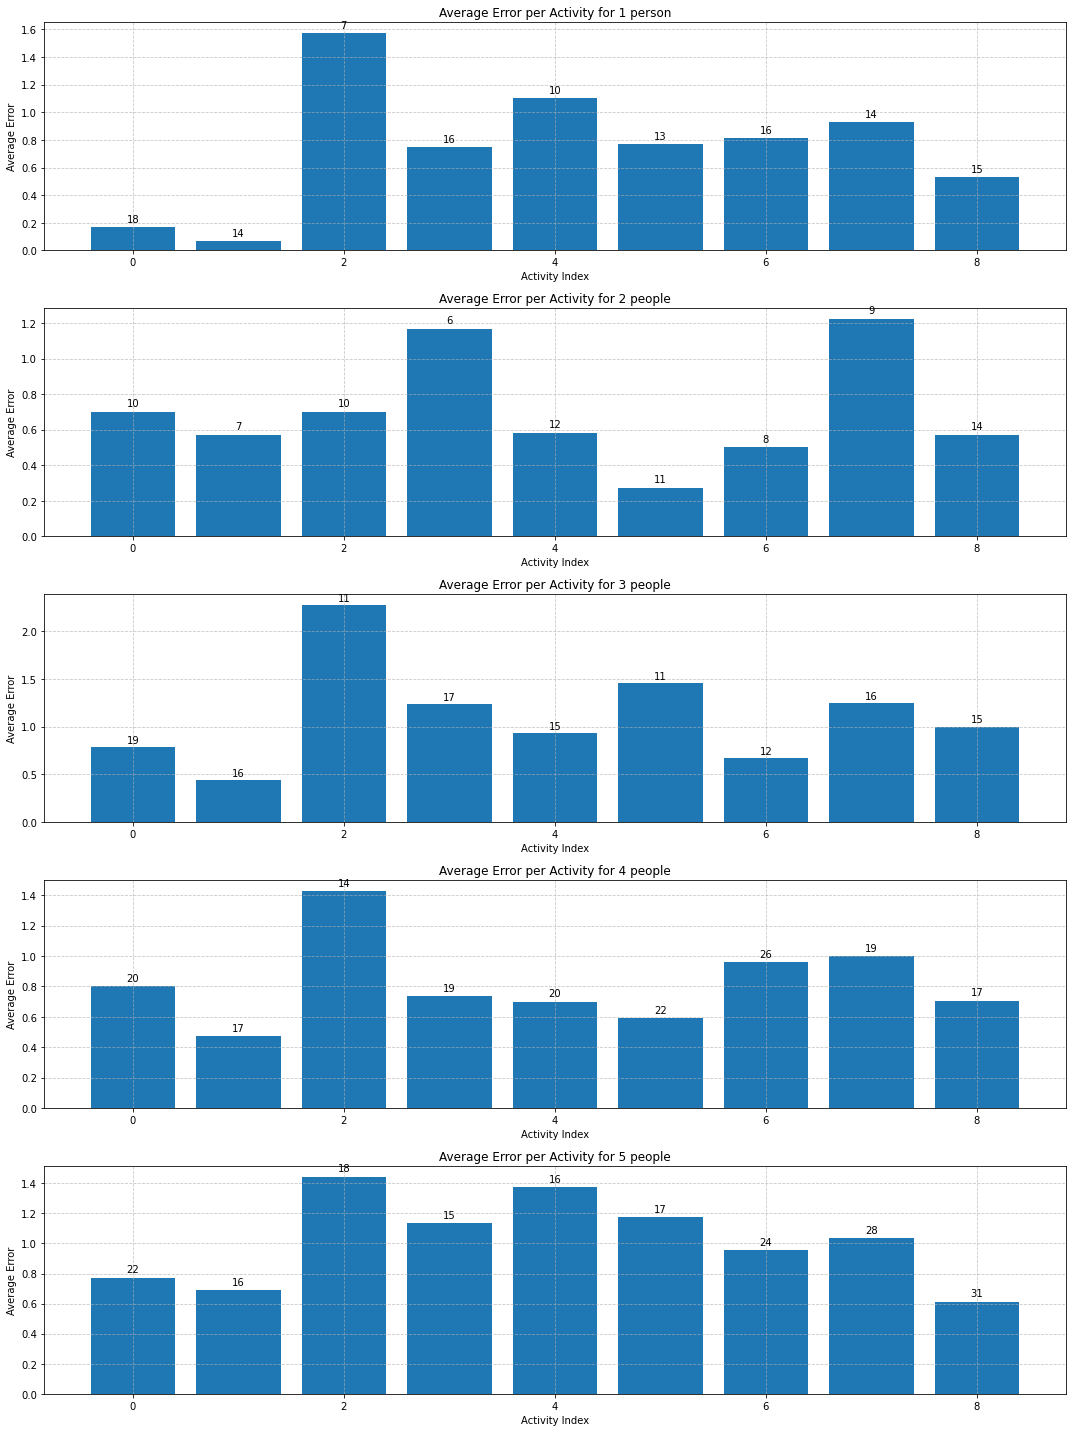

In [44]:
# Let's look at the average error per activity for each person count
plt.figure(figsize=(15, 20))  # Increased height from 10 to 20

for i, count in enumerate(sorted(performance_metrics.keys())):
    if count not in grouped_data:
        continue
        
    y_true_group, y_pred_group, _ = grouped_data[count]
    
    # Calculate absolute error per activity
    absolute_diff = np.abs(y_true_group - y_pred_group)
    sum_error_per_activity = np.sum(absolute_diff, axis=0)
    count_per_activity = np.sum(y_true_group > 0, axis=0)
    
    # Average error per activity (avoid division by zero)
    avg_error_per_activity = np.zeros(y_true_group.shape[1])
    for j in range(y_true_group.shape[1]):
        if count_per_activity[j] > 0:
            avg_error_per_activity[j] = sum_error_per_activity[j] / count_per_activity[j]
    
    # Only plot for activities with at least 1 occurrence
    valid_activities = np.where(count_per_activity > 0)[0]
    
    plt.subplot(len(performance_metrics), 1, i+1)
    bars = plt.bar(valid_activities, avg_error_per_activity[valid_activities])
    
    # Add count labels above bars
    for j, bar in enumerate(bars):
        activity_idx = valid_activities[j]
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{count_per_activity[activity_idx]}", ha='center', va='bottom')
    
    plt.title(f"Average Error per Activity for {count} {'person' if count==1 else 'people'}")
    plt.xlabel("Activity Index")
    plt.ylabel("Average Error")
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [40]:
def get_activity_combination(row):
    """Convert a row to an activity combination tuple"""
    return tuple((i, int(count)) for i, count in enumerate(row) if count > 0)

# Analyze activity combinations for each group
for count in sorted(performance_metrics.keys()):
    if count == 1 or count not in grouped_data:  # Skip single-person scenario
        continue
        
    print(f"\n===== Activity Combinations for {count} people =====")
    
    y_true_group, y_pred_group, _ = grouped_data[count]
    
    # Extract activity combinations
    true_combinations = [get_activity_combination(row) for row in y_true_group]
    pred_combinations = [get_activity_combination(row) for row in y_pred_group]
    
    # Count occurrences of each combination
    from collections import Counter
    true_combo_counts = Counter(true_combinations)
    
    # Get most common combinations
    most_common = true_combo_counts.most_common(5)
    
    print(f"Top {len(most_common)} activity combinations for {count} people:")
    for combo, frequency in most_common:
        # Format combination for display
        combo_str = " + ".join([f"{count} people doing activity {act}" for act, count in combo])
        
        # Calculate how often this combination is correctly predicted
        correct_count = sum(1 for i, true_combo in enumerate(true_combinations) 
                          if true_combo == combo and pred_combinations[i] == combo)
        
        accuracy = correct_count / frequency if frequency > 0 else 0
        print(f"  {combo_str}: {frequency} occurrences, accuracy: {accuracy:.2f}")


===== Activity Combinations for 2 people =====
Top 5 activity combinations for 2 people:
  1 people doing activity 0 + 1 people doing activity 8: 6 occurrences, accuracy: 0.50
  1 people doing activity 4 + 1 people doing activity 5: 5 occurrences, accuracy: 0.20
  2 people doing activity 7: 5 occurrences, accuracy: 0.80
  1 people doing activity 2 + 1 people doing activity 3: 4 occurrences, accuracy: 0.75
  2 people doing activity 2: 4 occurrences, accuracy: 0.50

===== Activity Combinations for 3 people =====
Top 5 activity combinations for 3 people:
  2 people doing activity 3 + 1 people doing activity 4: 4 occurrences, accuracy: 0.00
  3 people doing activity 0: 4 occurrences, accuracy: 0.50
  1 people doing activity 0 + 1 people doing activity 1 + 1 people doing activity 4: 3 occurrences, accuracy: 0.00
  1 people doing activity 0 + 1 people doing activity 7 + 1 people doing activity 8: 3 occurrences, accuracy: 0.00
  2 people doing activity 0 + 1 people doing activity 1: 3 occurr

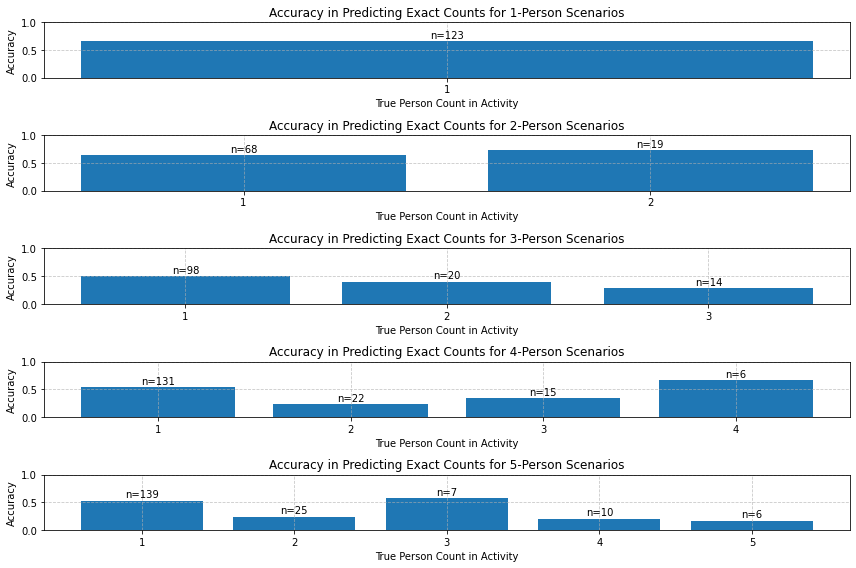

In [41]:
# For each group, analyze how well the model predicts the exact count
plt.figure(figsize=(12, 8))

# Store accuracy by true count
count_prediction_accuracy = {}

for count in sorted(performance_metrics.keys()):
    if count not in grouped_data:
        continue
        
    y_true_group, y_pred_group, _ = grouped_data[count]
    
    # For each possible person count (1-5), calculate how often the model predicts exactly that number
    accuracy_by_count = {}
    
    for true_count in range(1, 6):
        # Find positions with exactly this count in true labels
        matching_positions = []
        for i in range(len(y_true_group)):
            for j in range(y_true_group.shape[1]):
                if y_true_group[i, j] == true_count:
                    matching_positions.append((i, j))
        
        if matching_positions:
            # Calculate how often the prediction matches exactly
            correct = sum(1 for i, j in matching_positions if y_pred_group[i, j] == true_count)
            accuracy = correct / len(matching_positions)
            accuracy_by_count[true_count] = (accuracy, len(matching_positions))
    
    count_prediction_accuracy[count] = accuracy_by_count

# Plot accuracy for predicting exact counts
for i, count in enumerate(sorted(count_prediction_accuracy.keys())):
    accuracy_data = count_prediction_accuracy[count]
    
    true_counts = []
    accuracies = []
    sample_counts = []
    
    for true_count, (accuracy, samples) in sorted(accuracy_data.items()):
        true_counts.append(true_count)
        accuracies.append(accuracy)
        sample_counts.append(samples)
    
    plt.subplot(len(count_prediction_accuracy), 1, i+1)
    bars = plt.bar(true_counts, accuracies)
    
    # Add sample count labels
    for j, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"n={sample_counts[j]}", ha='center', va='bottom')
    
    plt.title(f"Accuracy in Predicting Exact Counts for {count}-Person Scenarios")
    plt.xlabel("True Person Count in Activity")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(true_counts)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Create a summary dataframe for easy comparison
summary_data = []

for count in sorted(performance_metrics.keys()):
    if count in performance_metrics:
        metrics = performance_metrics[count]
        summary_data.append({
            'People Count': count,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1 Score': metrics['f1_score'],
            'Perfect Prediction %': metrics['perfect_prediction_percentage'],
            'Error per Person': metrics['error_per_person'],
            'Mean Count Error': metrics['mean_count_error']
        })

summary_df = pd.DataFrame(summary_data)
print("Summary of Performance Metrics by People Count:")
print(summary_df)

# Overall conclusions
print("\n===== Analysis Conclusions =====")
print("Based on the analysis, here are the key findings:")

# Compare performance across different people counts
if len(performance_metrics) > 1:
    # Find best and worst performing scenarios
    f1_scores = {count: metrics['f1_score'] for count, metrics in performance_metrics.items()}
    best_count = max(f1_scores, key=f1_scores.get)
    worst_count = min(f1_scores, key=f1_scores.get)
    
    print(f"1. The model performs best for {best_count}-person scenarios (F1: {f1_scores[best_count]:.4f})")
    print(f"2. The model performs worst for {worst_count}-person scenarios (F1: {f1_scores[worst_count]:.4f})")
    
    # Check if error per person increases with more people
    error_per_person = {count: metrics['error_per_person'] for count, metrics in performance_metrics.items()}
    if all(error_per_person[i] <= error_per_person[i+1] for i in range(min(error_per_person.keys()), max(error_per_person.keys()))):
        print("3. Error per person consistently increases as the number of people increases")
    elif all(error_per_person[i] >= error_per_person[i+1] for i in range(min(error_per_person.keys()), max(error_per_person.keys()))):
        print("3. Error per person consistently decreases as the number of people increases")
    else:
        print("3. Error per person varies non-monotonically with the number of people")


Summary of Performance Metrics by People Count:
   People Count  Precision    Recall  F1 Score  Perfect Prediction %  \
0             1   0.665555  0.655274  0.643842             66.666667   
1             2   0.747146  0.738734  0.725773             54.716981   
2             3   0.597180  0.677202  0.624891             13.333333   
3             4   0.716266  0.696199  0.703556             14.754098   
4             5   0.666949  0.677096  0.664830             16.071429   

                           Error per Person  Mean Count Error  
0  [0.6666666666666666, nan, nan, nan, nan]          0.000000  
1  [nan, 1.0943396226415094, nan, nan, nan]          0.000000  
2                [nan, nan, 2.35, nan, nan]          0.550000  
3  [nan, nan, nan, 2.3114754098360657, nan]          0.114754  
4  [nan, nan, nan, nan, 3.2857142857142856]          0.000000  

===== Analysis Conclusions =====
Based on the analysis, here are the key findings:
1. The model performs best for 2-person scenarios (


===== Perfectly Predicted Patterns for 1 People =====
Total samples with 1 people: 123
Perfectly predicted samples: 82 (66.67%)

Most common perfectly predicted patterns:
  A0:1: 17 occurrences (20.73% of perfect predictions)
  A1:1: 13 occurrences (15.85% of perfect predictions)
  A7:1: 11 occurrences (13.41% of perfect predictions)
  A5:1: 9 occurrences (10.98% of perfect predictions)
  A8:1: 9 occurrences (10.98% of perfect predictions)
  A6:1: 8 occurrences (9.76% of perfect predictions)
  A3:1: 6 occurrences (7.32% of perfect predictions)
  A4:1: 5 occurrences (6.10% of perfect predictions)
  A2:1: 4 occurrences (4.88% of perfect predictions)

Breakdown of perfectly predicted activities:
  Activity 0:
    1 people: 17 occurrences
  Activity 1:
    1 people: 13 occurrences
  Activity 2:
    1 people: 4 occurrences
  Activity 3:
    1 people: 6 occurrences
  Activity 4:
    1 people: 5 occurrences
  Activity 5:
    1 people: 9 occurrences
  Activity 6:
    1 people: 8 occurrences
 

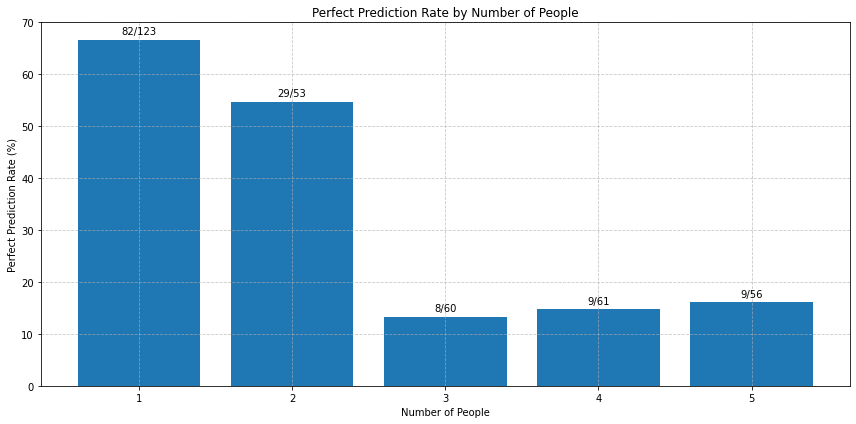

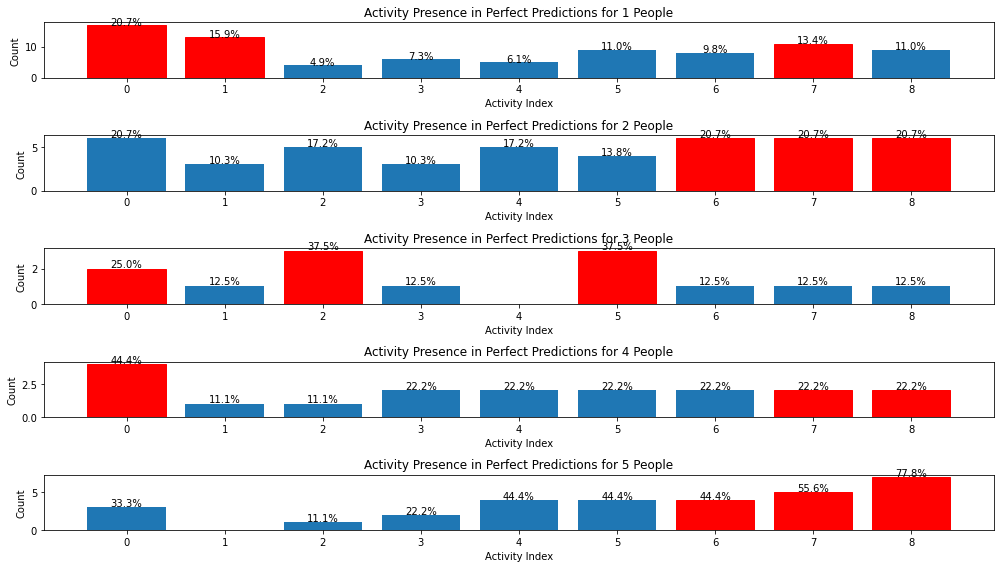


Top 15 Perfectly Predicted Patterns Across All People Counts:


,pattern,people_count,frequency,percentage
0,A0:1,1,17,20.731707
4,A1:1,1,13,15.853659
8,A7:1,1,11,13.414634
3,A8:1,1,9,10.975610
2,A5:1,1,9,10.975610
7,A6:1,1,8,9.756098
6,A3:1,1,6,7.317073
5,A4:1,1,5,6.097561
11,A7:2,2,4,13.793103
1,A2:1,1,4,4.878049


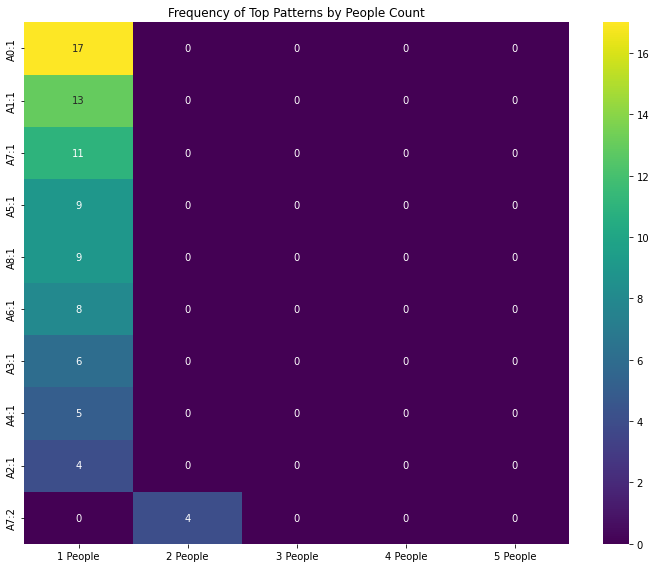

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Define helper function to check if a sample is perfectly predicted
def is_perfect_prediction(y_true_row, y_pred_row):
    """Check if prediction exactly matches the ground truth."""
    return np.array_equal(y_true_row, y_pred_row)

# Function to extract activity patterns from a sample
def extract_pattern(row):
    """Convert a row to a readable activity pattern."""
    activities = []
    for i, count in enumerate(row):
        if count > 0:
            activities.append(f"A{i}:{int(count)}")  # Activity index : count
    return ", ".join(activities) if activities else "None"

def analyze_perfect_predictions(y_test, y_pred):
    """Analyze perfectly predicted patterns for each people count."""
    # Calculate total people per sample
    people_per_sample = np.sum(y_test, axis=1)
    
    # Store results
    results = {}
    
    # For each people count (1-5)
    for count in range(1, 6):
        # Find samples with this many people
        count_indices = np.where(people_per_sample == count)[0]
        
        if len(count_indices) == 0:
            print(f"No samples found with {count} people")
            continue
            
        # Extract these samples
        y_true_group = y_test[count_indices]
        y_pred_group = y_pred[count_indices]
        
        # Find perfectly predicted samples
        perfect_mask = np.array([is_perfect_prediction(y_true_group[i], y_pred_group[i]) 
                                 for i in range(len(y_true_group))])
        perfect_indices = np.where(perfect_mask)[0]
        
        # Get the original indices in the full dataset
        original_perfect_indices = count_indices[perfect_indices]
        
        # Extract the perfectly predicted samples
        perfect_samples = y_true_group[perfect_indices]
        
        print(f"\n===== Perfectly Predicted Patterns for {count} People =====")
        print(f"Total samples with {count} people: {len(count_indices)}")
        print(f"Perfectly predicted samples: {len(perfect_indices)} ({(len(perfect_indices)/len(count_indices)*100):.2f}%)")
        
        if len(perfect_indices) == 0:
            print("No perfectly predicted samples to analyze")
            continue
        
        # Convert to readable patterns
        patterns = [extract_pattern(row) for row in perfect_samples]
        
        # Count pattern frequencies
        pattern_counts = Counter(patterns)
        most_common = pattern_counts.most_common()
        
        print("\nMost common perfectly predicted patterns:")
        for pattern, freq in most_common[:10]:  # Show top 10
            print(f"  {pattern}: {freq} occurrences ({(freq/len(perfect_indices)*100):.2f}% of perfect predictions)")
        
        # Analyze individual activities in perfect predictions
        activity_presence = np.sum(perfect_samples > 0, axis=0)
        activities_with_data = np.where(activity_presence > 0)[0]
        
        # Store for plotting
        results[count] = {
            'total_samples': len(count_indices),
            'perfect_samples': len(perfect_indices),
            'perfect_ratio': len(perfect_indices)/len(count_indices),
            'perfect_patterns': perfect_samples,
            'pattern_counts': pattern_counts,
            'activity_presence': activity_presence
        }
        
        # Analyze individual activity counts in perfect predictions
        print("\nBreakdown of perfectly predicted activities:")
        for act_idx in activities_with_data:
            # For this activity, find all non-zero counts that appeared in perfect predictions
            act_counts = [int(sample[act_idx]) for sample in perfect_samples if sample[act_idx] > 0]
            count_freq = Counter(act_counts)
            
            print(f"  Activity {act_idx}:")
            for act_count, freq in sorted(count_freq.items()):
                print(f"    {act_count} people: {freq} occurrences")
        
        # For multi-person scenarios, analyze concurrent activities
        if count > 1:
            print("\nActivity combinations in perfect predictions:")
            # Count how many activities were active simultaneously
            activity_counts = np.sum(perfect_samples > 0, axis=1)
            count_freq = Counter(activity_counts)
            
            for act_count, freq in sorted(count_freq.items()):
                print(f"  {act_count} simultaneous activities: {freq} occurrences ({(freq/len(perfect_indices)*100):.2f}%)")
    
    return results

# Visualize the results
def visualize_perfect_predictions(results):
    """Create visualizations for the analysis results."""
    if not results:
        print("No results to visualize")
        return
    
    # 1. Plot perfect prediction rates by people count
    plt.figure(figsize=(12, 6))
    counts = sorted(results.keys())
    perfect_ratios = [results[count]['perfect_ratio'] * 100 for count in counts]
    
    plt.bar(counts, perfect_ratios)
    plt.xlabel('Number of People')
    plt.ylabel('Perfect Prediction Rate (%)')
    plt.title('Perfect Prediction Rate by Number of People')
    plt.xticks(counts)
    
    # Add count labels
    for i, count in enumerate(counts):
        plt.text(count, perfect_ratios[i] + 1, 
                 f"{results[count]['perfect_samples']}/{results[count]['total_samples']}", 
                 ha='center')
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 2. Plot activity presence in perfect predictions
    plt.figure(figsize=(14, 8))
    
    # Plot for each people count
    for i, count in enumerate(counts):
        # Get activity presence data
        activity_presence = results[count]['activity_presence']
        if np.sum(activity_presence) == 0:
            continue
            
        plt.subplot(len(counts), 1, i+1)
        activity_indices = np.arange(len(activity_presence))
        bars = plt.bar(activity_indices, activity_presence)
        
        # Highlight most common activities
        top_activities = np.argsort(activity_presence)[-3:][::-1]  # Top 3
        for act in top_activities:
            if activity_presence[act] > 0:
                bars[act].set_color('red')
        
        plt.title(f"Activity Presence in Perfect Predictions for {count} People")
        plt.xlabel('Activity Index')
        plt.ylabel('Count')
        plt.xticks(activity_indices)
        
        # Add percentage labels
        total_perfect = results[count]['perfect_samples']
        for j, v in enumerate(activity_presence):
            if v > 0:
                plt.text(j, v + 0.1, f"{(v/total_perfect*100):.1f}%", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Analyze activity combinations across different people counts
    all_patterns = []
    for count in counts:
        # Skip if no perfect predictions
        if results[count]['perfect_samples'] == 0:
            continue
            
        # Get all patterns for this count
        patterns = results[count]['pattern_counts']
        for pattern, freq in patterns.items():
            all_patterns.append({
                'pattern': pattern,
                'people_count': count,
                'frequency': freq,
                'percentage': freq / results[count]['perfect_samples'] * 100
            })
    
    # Create and display dataframe of top patterns across all counts
    if all_patterns:
        pattern_df = pd.DataFrame(all_patterns)
        pattern_df = pattern_df.sort_values('frequency', ascending=False)
        
        print("\nTop 15 Perfectly Predicted Patterns Across All People Counts:")
        display(pattern_df.head(15))
        
        # Create a heatmap for common patterns across people counts
        # First get top patterns overall
        top_patterns = pattern_df.groupby('pattern')['frequency'].sum().nlargest(10).index.tolist()
        
        # Create a matrix for the heatmap
        heatmap_data = np.zeros((len(top_patterns), len(counts)))
        
        for i, pattern in enumerate(top_patterns):
            for j, count in enumerate(counts):
                if pattern in results[count]['pattern_counts']:
                    heatmap_data[i, j] = results[count]['pattern_counts'][pattern]
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='viridis',
                    xticklabels=[f"{c} People" for c in counts],
                    yticklabels=top_patterns)
        plt.title('Frequency of Top Patterns by People Count')
        plt.tight_layout()
        plt.show()

# Run the analysis with your data
# Uncomment and run this with your real data
results = analyze_perfect_predictions(y_test, y_pred)
visualize_perfect_predictions(results)